# MASTER THESIS - night ventilation strategies

This notebook demonstrates the usage of the `DarkGreyBox` models via fitting them with `DarkGreyFit`

Model used: 
##### TiTmCn2R2C_summer_V9

Period:
##### 01/09 --> 15/09

## Importation

In [1]:
import sys
import importlib
from pathlib import Path
import pvlib
from scipy.interpolate import BSpline

# go from ...\docs\tutorials up two levels to the repo root (...\darkgreybox)
repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root))
importlib.invalidate_caches()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from statsmodels.graphics.tsaplots import plot_pacf

from darkgreybox.models import TiTmCn2R2C_summer_V9
from darkgreybox.night_ventilation import simulate_night_vent_scenario, comfort_metrics
from darkgreybox.fit import darkgreyfit
from docs.tutorials.util.plot import plot
from docs.tutorials.util.error import rmse

C:\Users\clemr\AppData\Roaming\Python\Python311\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


2026-04-15 18:26:12,883 darkgreybox  INFO     Logging enabled...


In [2]:
rec_duration = 60/60

In [3]:
import pickle

class MockResult:
    def __init__(self, Z, var=None):
        self.Z   = Z
        self.var = var if var is not None else {}

RESULTS_FILE = "simulation_results_mcmc_2025_full_hourly.pkl"

with open(RESULTS_FILE, "rb") as f:
    saved = pickle.load(f)

df           = saved["df"]
X_train      = saved["X_train"]
y_train      = saved["y_train"]
X_test       = saved["X_test"]
y_test       = saved["y_test"]
model        = saved["model"]

train_results = saved["train_results"]
test_results  = saved["test_results"]

print(f"Loaded! DataFrame shape: {df.shape}")

Loaded! DataFrame shape: (1, 13)


## Train results

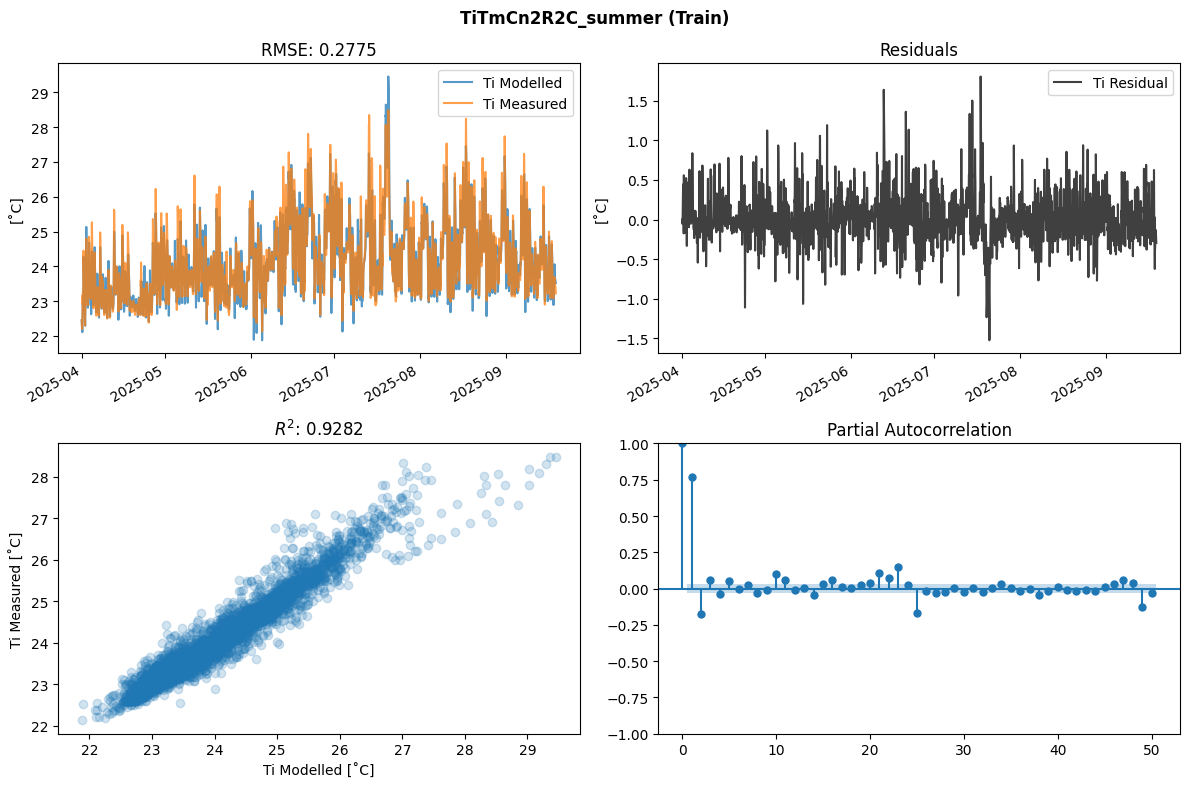

In [4]:
plot(y_train, train_results, 'TiTmCn2R2C_summer (Train)')

## Test results

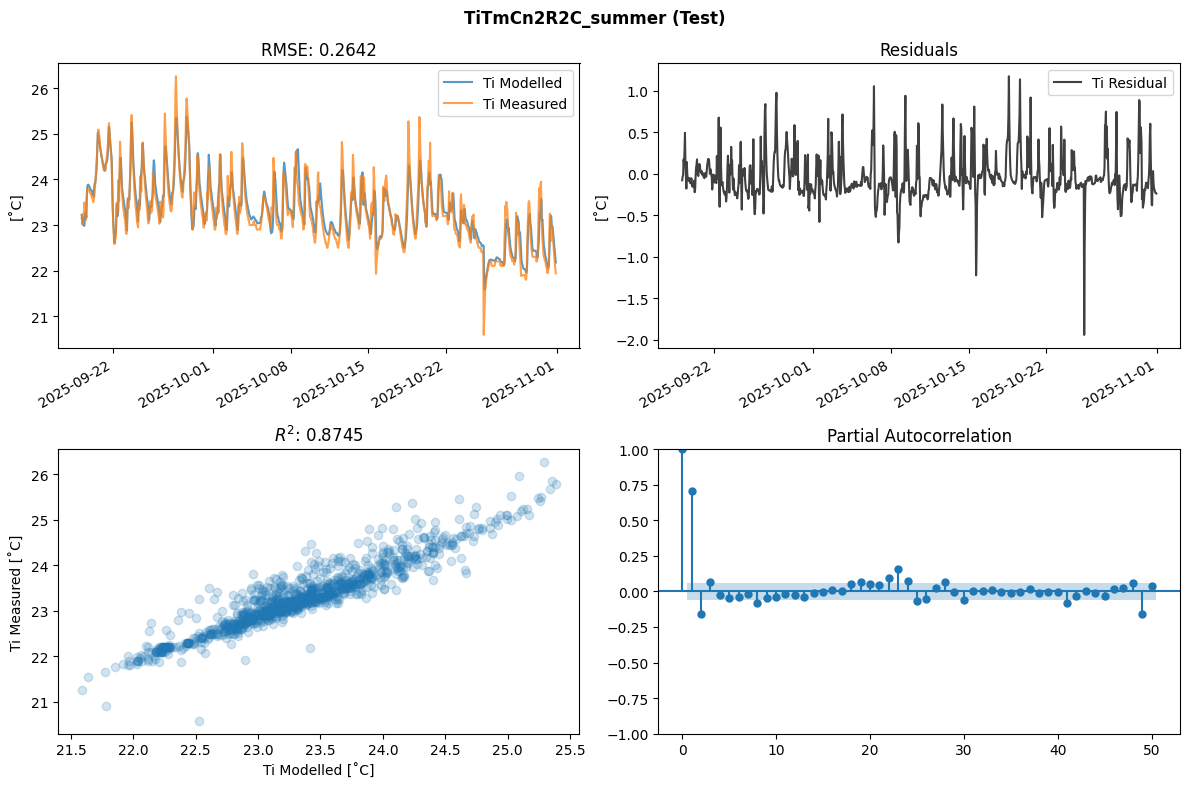

In [5]:
plot(y_test, test_results, 'TiTmCn2R2C_summer (Test)')

# Plot the main results

Using variables already in memory.


C:\Users\clemr\AppData\Roaming\Python\Python311\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: overflow encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\clemr\AppData\Roaming\Python\Python311\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
C:\Users\clemr\AppData\Roaming\Python\Python311\site-packages\matplotlib\ticker.py:2178: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale


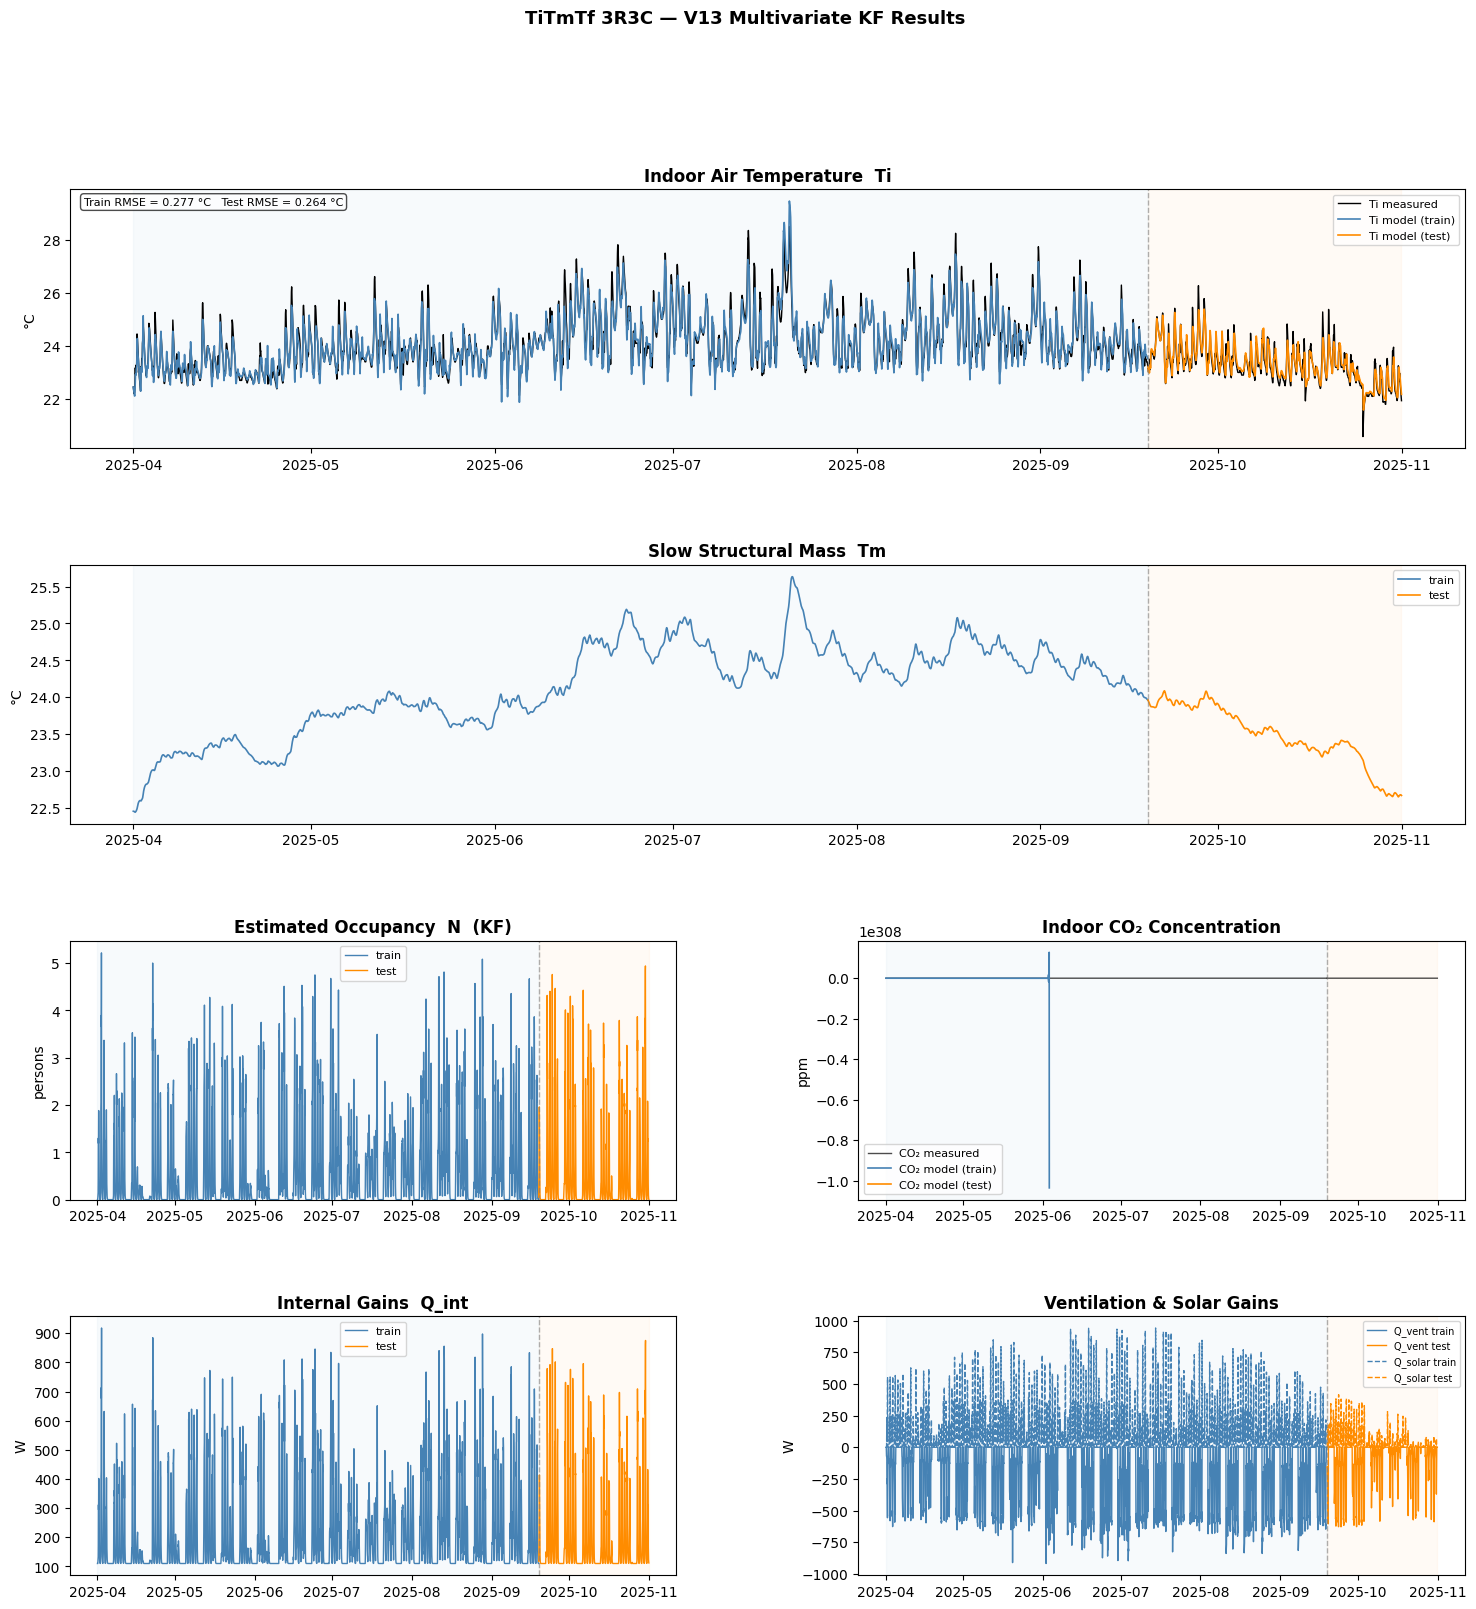

In [7]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

RESULTS_FILE = "simulation_results.pkl"

# ── Load from pickle if variables are not already in memory ──────────────────
if 'df' not in dir() or 'y_train' not in dir():
    print("Variables not in memory — loading from saved file...")
    with open(RESULTS_FILE, "rb") as f:
        saved = pickle.load(f)
    df            = saved["df"]
    X_train       = saved["X_train"]
    y_train       = saved["y_train"]
    X_test        = saved["X_test"]
    y_test        = saved["y_test"]
    model         = saved["model"]
    train_results = saved["train_results"]
    test_results  = saved["test_results"]
    print("Loaded successfully!")
else:
    print("Using variables already in memory.")

# ── get_var: handles DarkGreyModelResult attribute-based access ───────────────
def get_var(result, key):
    if key in result.var:
        return np.asarray(result.var[key], dtype=float)
    print(f"Warning: '{key}' not found in result.var. Available keys: {list(result.var.keys())}")
    return None

def rmse(pred, actual):
    return np.sqrt(np.mean((np.asarray(pred) - np.asarray(actual)) ** 2))

# ── Reconstruct time index ────────────────────────────────────────────────────
train_index = X_train.index
test_index  = X_test.index

# ── Unpack results ────────────────────────────────────────────────────────────
Ti_train   = get_var(train_results, 'Ti')
Tm_train   = get_var(train_results, 'Tm')
N_train    = get_var(train_results, 'N')
c_train    = get_var(train_results, 'c')
Qint_train = get_var(train_results, 'Q_int')
Qven_train = get_var(train_results, 'Q_vent')
Qsol_train = get_var(train_results, 'Q_solar')

Ti_test    = get_var(test_results, 'Ti')
Tm_test    = get_var(test_results, 'Tm')
N_test     = get_var(test_results, 'N')
c_test     = get_var(test_results, 'c')
Qint_test  = get_var(test_results, 'Q_int')
Qven_test  = get_var(test_results, 'Q_vent')
Qsol_test  = get_var(test_results, 'Q_solar')

c_meas_train = np.asarray(X_train['c'], dtype=float)
c_meas_test  = np.asarray(X_test['c'],  dtype=float)

# ── Figure layout — 4 rows ────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 18))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3)

ax_ti   = fig.add_subplot(gs[0, :])
ax_tm   = fig.add_subplot(gs[1, :])
ax_n    = fig.add_subplot(gs[2, 0])
ax_co2  = fig.add_subplot(gs[2, 1])
ax_qint = fig.add_subplot(gs[3, 0])
ax_qven = fig.add_subplot(gs[3, 1])

def shade_split(ax):
    ax.axvline(test_index[0], color='grey', lw=1, ls='--', alpha=0.6)
    ax.axvspan(train_index[0], test_index[0],  alpha=0.04, color='steelblue')
    ax.axvspan(test_index[0],  test_index[-1], alpha=0.04, color='darkorange')

# ── 1. Ti ─────────────────────────────────────────────────────────────────────
ax_ti.plot(train_index, y_train,  color='black',      lw=1.0, label='Ti measured')
ax_ti.plot(train_index, Ti_train, color='steelblue',  lw=1.2, label='Ti model (train)')
ax_ti.plot(test_index,  y_test,   color='black',      lw=1.0)
ax_ti.plot(test_index,  Ti_test,  color='darkorange', lw=1.2, label='Ti model (test)')
shade_split(ax_ti)
ax_ti.set_title('Indoor Air Temperature  Ti', fontweight='bold')
ax_ti.set_ylabel('°C')
ax_ti.legend(fontsize=8)
ax_ti.text(0.01, 0.97,
    f'Train RMSE = {rmse(Ti_train, y_train.values):.3f} °C   '
    f'Test RMSE = {rmse(Ti_test, y_test.values):.3f} °C',
    transform=ax_ti.transAxes, va='top', fontsize=8,
    bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── 2. Tm ─────────────────────────────────────────────────────────────────────
ax_tm.plot(train_index, Tm_train, color='steelblue',  lw=1.2, label='train')
ax_tm.plot(test_index,  Tm_test,  color='darkorange', lw=1.2, label='test')
shade_split(ax_tm)
ax_tm.set_title('Slow Structural Mass  Tm', fontweight='bold')
ax_tm.set_ylabel('°C')
ax_tm.legend(fontsize=8)

# ── 3. Occupancy N ────────────────────────────────────────────────────────────
ax_n.plot(train_index, N_train, color='steelblue',  lw=1.0, label='train')
ax_n.plot(test_index,  N_test,  color='darkorange', lw=1.0, label='test')
ax_n.set_ylim(bottom=0)
shade_split(ax_n)
ax_n.set_title('Estimated Occupancy  N  (KF)', fontweight='bold')
ax_n.set_ylabel('persons')
ax_n.legend(fontsize=8)

# ── 4. CO2 ────────────────────────────────────────────────────────────────────
ax_co2.plot(train_index, c_meas_train, color='black',      lw=1.0, alpha=0.7, label='CO₂ measured')
ax_co2.plot(train_index, c_train,      color='steelblue',  lw=1.2, label='CO₂ model (train)')
ax_co2.plot(test_index,  c_meas_test,  color='black',      lw=1.0, alpha=0.7)
ax_co2.plot(test_index,  c_test,       color='darkorange', lw=1.2, label='CO₂ model (test)')
shade_split(ax_co2)
ax_co2.set_title('Indoor CO₂ Concentration', fontweight='bold')
ax_co2.set_ylabel('ppm')
ax_co2.legend(fontsize=8)

# ── 5. Internal heat gains ────────────────────────────────────────────────────
ax_qint.plot(train_index, Qint_train, color='steelblue',  lw=1.0, label='train')
ax_qint.plot(test_index,  Qint_test,  color='darkorange', lw=1.0, label='test')
shade_split(ax_qint)
ax_qint.set_title('Internal Gains  Q_int', fontweight='bold')
ax_qint.set_ylabel('W')
ax_qint.legend(fontsize=8)

# ── 6. Ventilation + solar ────────────────────────────────────────────────────
ax_qven.plot(train_index, Qven_train, color='steelblue',  lw=1.0, label='Q_vent train')
ax_qven.plot(test_index,  Qven_test,  color='darkorange', lw=1.0, label='Q_vent test')
ax_qven.plot(train_index, Qsol_train, color='steelblue',  lw=1.0, ls='--', label='Q_solar train')
ax_qven.plot(test_index,  Qsol_test,  color='darkorange', lw=1.0, ls='--', label='Q_solar test')
shade_split(ax_qven)
ax_qven.set_title('Ventilation & Solar Gains', fontweight='bold')
ax_qven.set_ylabel('W')
ax_qven.legend(fontsize=7)

# ── Save & show ───────────────────────────────────────────────────────────────
fig.suptitle('TiTmTf 3R3C — V13 Multivariate KF Results',
             fontsize=13, fontweight='bold')
plt.savefig('V13_results.png', dpi=150, bbox_inches='tight')
plt.show()


# NIGHT VENTILATION

## Analysis of the existing behaviour

  EXISTING NIGHT VENTILATION ANALYSIS
  Night window           : 22:00 – 07:00
  qv threshold used      : 0.0 m³/h
  Night steps total      : 1543
  Night vent active      : 790 steps  (51.2%)
  Free cooling active    : 790 steps  (51.2%)
  Missed opportunities   : 753 steps  (48.8%)
  Mean qv (night, active): 167.2 m³/h
  Max  qv (night)        : 275.2 m³/h
  Mean qv (daytime)      : 98.5 m³/h
  Mean ΔT when active    : 9.29 °C  (Ti − Ta)
  Mean ΔT missed opport. : 12.10 °C  (Ti − Ta)


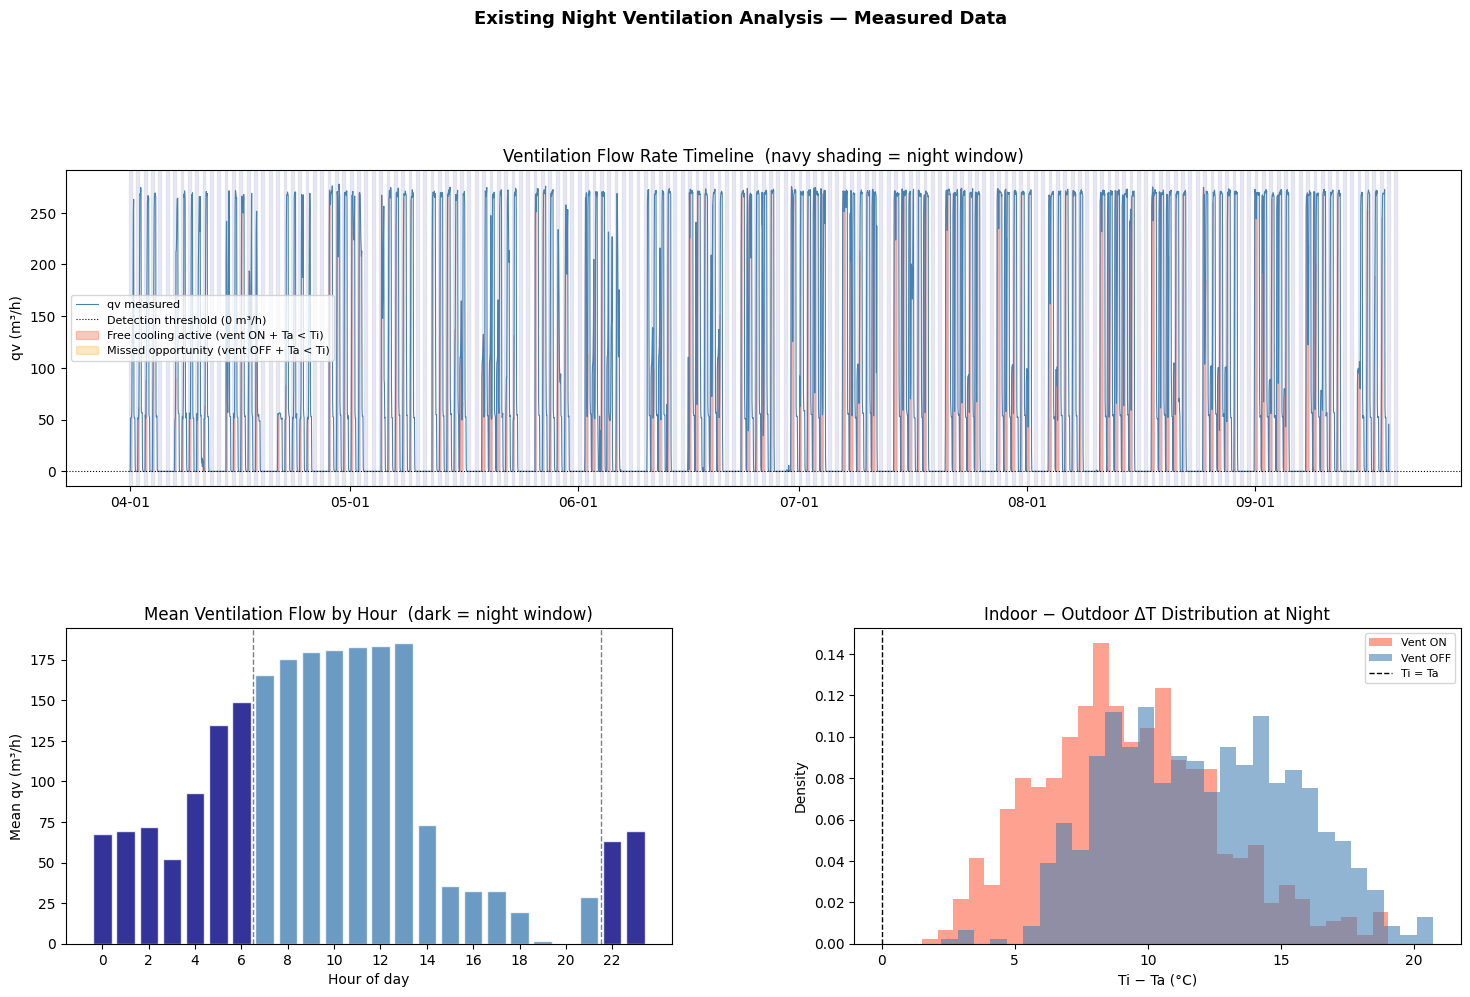

In [8]:
# ════════════════════════════════════════════════════════════════════════════
#  NIGHT VENTILATION ANALYSIS — existing behaviour in measured data
# ════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ── Config ───────────────────────────────────────────────────────────────────
NIGHT_START   = 22      # hour (inclusive)
NIGHT_STOP    = 7       # hour (exclusive, crosses midnight)
QV_THRESHOLD  = float(np.percentile(np.asarray(X_train['qv'], dtype=float), 25))
                        # anything above 25th percentile at night = "ventilation active"

# ── Raw arrays ───────────────────────────────────────────────────────────────
index   = X_train.index
qv_arr  = np.asarray(X_train['qv'],  dtype=float)
Ta_arr  = np.asarray(X_train['Ta'],  dtype=float)
Ti_meas = np.asarray(y_train,        dtype=float)
hours   = np.array([t.hour + t.minute / 60.0 for t in index])
dt_h    = (index[1] - index[0]).seconds / 3600.0

# ── Night mask (crosses midnight) ────────────────────────────────────────────
night_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)

# ── Detect night ventilation events ──────────────────────────────────────────
night_vent_active = night_mask & (qv_arr > QV_THRESHOLD)
free_cooling_ok   = night_mask & (qv_arr > QV_THRESHOLD) & (Ta_arr < Ti_meas)
free_cooling_miss = night_mask & (qv_arr <= QV_THRESHOLD) & (Ta_arr < Ti_meas)
                    # night, no vent, but outdoor is cooler → missed opportunity

# ── Summary statistics ────────────────────────────────────────────────────────
n_night_steps        = night_mask.sum()
n_vent_steps         = night_vent_active.sum()
n_free_cooling_steps = free_cooling_ok.sum()
n_missed_steps       = free_cooling_miss.sum()

pct_night_vented     = 100 * n_vent_steps / n_night_steps if n_night_steps > 0 else 0
pct_free_cooling     = 100 * n_free_cooling_steps / n_night_steps if n_night_steps > 0 else 0
pct_missed           = 100 * n_missed_steps / n_night_steps if n_night_steps > 0 else 0

qv_night_mean = qv_arr[night_vent_active].mean() if n_vent_steps > 0 else 0
qv_night_max  = qv_arr[night_vent_active].max()  if n_vent_steps > 0 else 0
qv_day_mean   = qv_arr[~night_mask].mean()

delta_T_free  = (Ti_meas - Ta_arr)[free_cooling_ok]   # Ti - Ta when free cooling active
delta_T_miss  = (Ti_meas - Ta_arr)[free_cooling_miss]  # Ti - Ta when opportunity missed

print("=" * 60)
print("  EXISTING NIGHT VENTILATION ANALYSIS")
print("=" * 60)
print(f"  Night window           : {NIGHT_START}:00 – {NIGHT_STOP:02d}:00")
print(f"  qv threshold used      : {QV_THRESHOLD:.1f} m³/h")
print(f"  Night steps total      : {n_night_steps}")
print(f"  Night vent active      : {n_vent_steps} steps  ({pct_night_vented:.1f}%)")
print(f"  Free cooling active    : {n_free_cooling_steps} steps  ({pct_free_cooling:.1f}%)")
print(f"  Missed opportunities   : {n_missed_steps} steps  ({pct_missed:.1f}%)")
print(f"  Mean qv (night, active): {qv_night_mean:.1f} m³/h")
print(f"  Max  qv (night)        : {qv_night_max:.1f} m³/h")
print(f"  Mean qv (daytime)      : {qv_day_mean:.1f} m³/h")
if len(delta_T_free) > 0:
    print(f"  Mean ΔT when active    : {delta_T_free.mean():.2f} °C  (Ti − Ta)")
if len(delta_T_miss) > 0:
    print(f"  Mean ΔT missed opport. : {delta_T_miss.mean():.2f} °C  (Ti − Ta)")
print("=" * 60)

# ── Hourly profile: mean qv by hour ──────────────────────────────────────────
hour_int   = np.array([t.hour for t in index])
qv_by_hour = np.array([qv_arr[hour_int == h].mean() for h in range(24)])

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 16))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])   # full width — qv timeline
ax2 = fig.add_subplot(gs[1, 0])   # hourly qv profile
ax3 = fig.add_subplot(gs[1, 1])   # ΔT histogram (Ti - Ta) during night

fig.suptitle('Existing Night Ventilation Analysis — Measured Data', fontsize=13, fontweight='bold')

# ── 1. qv timeline with night shading ────────────────────────────────────────
ax1.plot(index, qv_arr, color='steelblue', lw=0.8, label='qv measured')
ax1.axhline(QV_THRESHOLD, color='black', lw=0.8, ls=':', label=f'Detection threshold ({QV_THRESHOLD:.0f} m³/h)')

# shade night periods
day_start = index[0].normalize()
for d in range((index[-1] - index[0]).days + 2):
    ns = day_start + pd.Timedelta(hours=NIGHT_START + d * 24 - 24)
    ne = day_start + pd.Timedelta(hours=NIGHT_STOP   + d * 24)
    ax1.axvspan(ns, ne, alpha=0.08, color='navy', zorder=0)

# mark free-cooling active steps
ax1.fill_between(index, qv_arr, 0,
    where=free_cooling_ok, alpha=0.35, color='tomato',
    label='Free cooling active (vent ON + Ta < Ti)')
ax1.fill_between(index, QV_THRESHOLD, 0,
    where=free_cooling_miss, alpha=0.25, color='orange',
    label='Missed opportunity (vent OFF + Ta < Ti)')

ax1.set_ylabel('qv (m³/h)')
ax1.legend(fontsize=8)
ax1.set_title('Ventilation Flow Rate Timeline  (navy shading = night window)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

# ── 2. Mean qv by hour of day ─────────────────────────────────────────────────
bar_colors = ['navy' if (h >= NIGHT_START or h < NIGHT_STOP) else 'steelblue'
              for h in range(24)]
ax2.bar(range(24), qv_by_hour, color=bar_colors, alpha=0.8, edgecolor='white')
ax2.axvline(NIGHT_START - 0.5, color='black', lw=1, ls='--', alpha=0.5)
ax2.axvline(NIGHT_STOP  - 0.5, color='black', lw=1, ls='--', alpha=0.5)
ax2.set_xlabel('Hour of day')
ax2.set_ylabel('Mean qv (m³/h)')
ax2.set_title('Mean Ventilation Flow by Hour  (dark = night window)')
ax2.set_xticks(range(0, 24, 2))

# ── 3. Histogram of ΔT = Ti − Ta during night ─────────────────────────────────
delta_T_all_night = (Ti_meas - Ta_arr)[night_mask]
ax3.hist(delta_T_all_night[night_vent_active[night_mask]],
         bins=30, color='tomato', alpha=0.6, label='Vent ON', density=True)
ax3.hist(delta_T_all_night[~night_vent_active[night_mask]],
         bins=30, color='steelblue', alpha=0.6, label='Vent OFF', density=True)
ax3.axvline(0, color='black', lw=1, ls='--', label='Ti = Ta')
ax3.set_xlabel('Ti − Ta (°C)')
ax3.set_ylabel('Density')
ax3.set_title('Indoor − Outdoor ΔT Distribution at Night')
ax3.legend(fontsize=8)


plt.savefig('night_vent_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## Setup

In [9]:
# ════════════════════════════════════════════════════════════════════════════
#  SETUP — Shared parameters, constants, and initial conditions
#  Run this cell once before any scenario / analysis / optimisation block
# ════════════════════════════════════════════════════════════════════════════

# ── Model fitted parameters ───────────────────────────────────────────────────
fitted_params = model.result.params          # lmfit / statsmodels params object

# ── Time index (derived from training data) ───────────────────────────────────
index   = X_train.index                      # DatetimeIndex shared by all blocks
dt_h    = (index[1] - index[0]).seconds / 3600.0   # timestep in hours

# ── Initial conditions (taken from the first training step) ───────────────────
Ti_init = float(y_train.iloc[0])             # Indoor air temperature  [°C]
Tm_init = float(train_results.var['Tm'][0])  # Thermal mass temperature [°C]
c_init  = float(train_results.var['c'][0])   # CO₂ concentration        [ppm]
N_hist  = train_results.var['N']             # Estimated occupancy series

# ── Ventilation flow bounds ───────────────────────────────────────────────────
QV_MIN  = 0.0      # m³/h — lower bound (fan off)
QV_MAX  = 250.0    # m³/h — upper bound (system capacity); adjust to your AHU

# ── Energy cost parameters ────────────────────────────────────────────────────
SFP     = 1.5      # W/(m³/h) — Specific Fan Power
P_ELEC  = 1.493    # DKK/kWh  — Danish commercial all-in tariff, DK2 zone

# ── Quick sanity check ────────────────────────────────────────────────────────
print(f"Index range   : {index[0]}  →  {index[-1]}")
print(f"Timestep      : {dt_h:.4f} h  ({dt_h*60:.1f} min)")
print(f"Ti_init       : {Ti_init:.2f} °C")
print(f"Tm_init       : {Tm_init:.2f} °C")
print(f"c_init        : {c_init:.1f} ppm")
print(f"QV bounds     : [{QV_MIN}, {QV_MAX}] m³/h")
print(f"SFP / P_ELEC  : {SFP} W/(m³/h)  /  {P_ELEC} DKK/kWh")

Index range   : 2025-04-01 00:00:00+00:00  →  2025-09-19 03:00:00+00:00
Timestep      : 1.0000 h  (60.0 min)
Ti_init       : 22.45 °C
Tm_init       : 22.45 °C
c_init        : 423.8 ppm
QV bounds     : [0.0, 250.0] m³/h
SFP / P_ELEC  : 1.5 W/(m³/h)  /  1.493 DKK/kWh


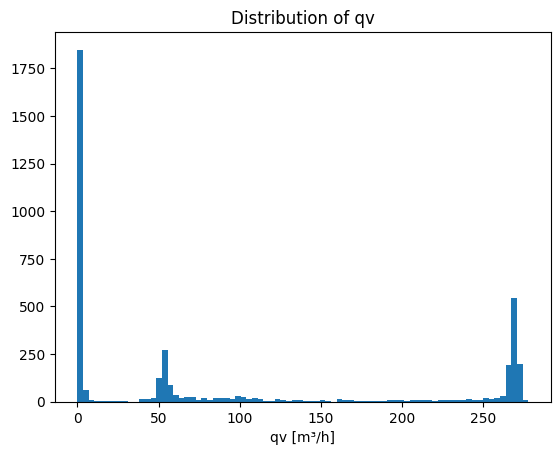

In [10]:
import matplotlib.pyplot as plt
import numpy as np

qv = np.asarray(X_train['qv'])
plt.hist(qv, bins=80)
plt.xlabel('qv [m³/h]')
plt.title('Distribution of qv')
plt.show()

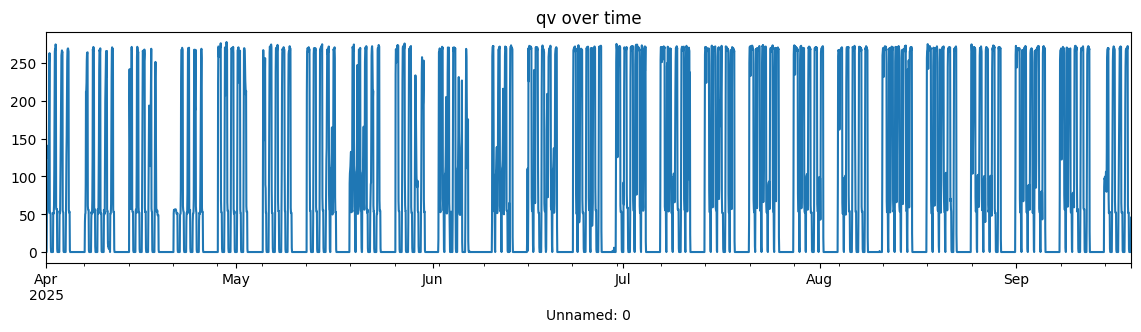

In [11]:
pd.Series(qv, index=index).plot(figsize=(14,3))
plt.title('qv over time')
plt.show()

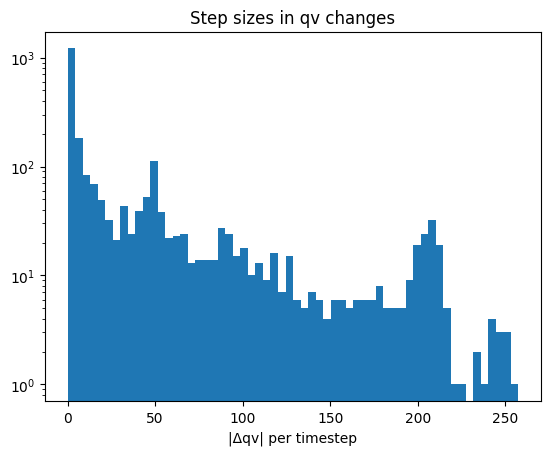

In [12]:
dqv = np.abs(np.diff(qv))
plt.hist(dqv[dqv > 0], bins=60, log=True)
plt.xlabel('|Δqv| per timestep')
plt.title('Step sizes in qv changes')
plt.show()

### Pre-computation block

In [18]:
# ════════════════════════════════════════════════════════════════════════════
#  PRE-COMPUTATION
# ════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt


# ── CONFIG ───────────────────────────────────────────────────────────────────
T_cat1_min        = 22.0   # Custom category: 22–24 °C (replaces EN16798 Cat II)
T_cat1_max        = 24.0
T_TARGET          = 23.0   # Setpoint ±1 °C deadband
TA_MIN_NIGHT_VENT = 14.0   # Min T_ext for night vent — condensation dew-point limit
NIGHT_START       = 22
NIGHT_STOP        = 7
OCC_START         = 8
OCC_END           = 18
dt_h              = rec_duration


# ── PHYSICAL CONSTANTS ───────────────────────────────────────────────────────
RHO_AIR  = 1.2      # kg/m³
CP_AIR   = 1005.0   # J/(kg·K)
COP_COOL = 3.0      # COP of cooling plant (electricity → cold)


# ── AIVC SFP MODEL  (variable-speed fan, fan-affinity law) ───────────────────
# SFP(qv) = SFP_ref · (qv / QV_ref)²   [Wh/m³]
# Natural ventilation qv = 0  →  SFP = 0  (no fan at all)
_SFP_REF = SFP      # Wh/m³ at QV_MAX
_QV_REF  = QV_MAX


def sfp_aivc(qv_array):
    """AIVC SFP [Wh/m³] — quadratic in flow (VSD, fan-affinity law)."""
    qv = np.asarray(qv_array, dtype=float)
    return np.where(qv > 0.0, _SFP_REF * (qv / _QV_REF) ** 2, 0.0)


def fan_cost_aivc(qv_array):
    """Fan electricity cost [DKK] — AIVC SFP(qv) model."""
    qv   = np.asarray(qv_array, dtype=float)
    P_kW = qv / 3.6 * sfp_aivc(qv) / 1000.0
    return float(np.sum(P_kW) * P_ELEC * dt_h)


def q_cool_cost(qv_array, T_ext_arr, T_sup_arr):
    """
    Cooling energy penalty when outdoor air is warmer than supply setpoint.
    Q_cool = qv/3600 · ρ · cₚ · max(0, T_ext − T_sup)   [W]
    Cost   = ΣQ_cool · dt_h / 1000 / COP_COOL · P_ELEC   [DKK]
    Disappears when Tsup = T_ext (night vent) — only penalises daytime HVAC.
    """
    qv    = np.asarray(qv_array,  dtype=float)
    T_ext = np.asarray(T_ext_arr, dtype=float)
    T_sup = np.asarray(T_sup_arr, dtype=float)
    delta = np.maximum(0.0, T_ext - T_sup)
    Q_kW  = (qv / 3600.0) * RHO_AIR * CP_AIR * delta / 1000.0
    return float(np.sum(Q_kW) * dt_h / COP_COOL * P_ELEC)


def total_system_cost(qv_array, T_ext_arr, T_sup_arr):
    """Total cost = AIVC fan cost + cooling energy penalty [DKK]."""
    return fan_cost_aivc(qv_array) + q_cool_cost(qv_array, T_ext_arr, T_sup_arr)


# ── TIME / WEEKDAY ARRAYS ────────────────────────────────────────────────────
hours    = np.array([t.hour + t.minute / 60.0 for t in index])
weekdays = np.array([t.weekday() for t in index])


# ── OCCUPANCY MASKS ──────────────────────────────────────────────────────────
occ_mask         = (hours >= OCC_START) & (hours < OCC_END)
weekday_day_mask = occ_mask & (weekdays < 5)


# ── NIGHT MASK ───────────────────────────────────────────────────────────────
if NIGHT_START > NIGHT_STOP:
    nighttime_mask = (hours >= NIGHT_START) | (hours < NIGHT_STOP)
else:
    nighttime_mask = (hours >= NIGHT_START) & (hours < NIGHT_STOP)


def _next_morning_is_weekday(t):
    ref = t + pd.Timedelta(days=1) if t.hour >= NIGHT_START else t
    return ref.weekday() < 5


weekday_night_mask = nighttime_mask & np.array(
    [_next_morning_is_weekday(t) for t in index])
weekend_night_mask = nighttime_mask & ~weekday_night_mask
all_night_mask     = nighttime_mask.copy()


# ── FREE-COOLING ELIGIBILITY (condensation constraint: T_ext > 14°C) ─────────
Ta_arr     = np.asarray(X_train['Ta'], dtype=float)
ta_ok_mask = Ta_arr > TA_MIN_NIGHT_VENT


# ── HELPER FUNCTIONS ─────────────────────────────────────────────────────────
def pct_in_band(Ti_series, Tmin, Tmax, mask):
    Ti = np.asarray(Ti_series)[mask]
    return float(np.mean((Ti >= Tmin) & (Ti <= Tmax)) * 100)


def fan_cost(qv_array):
    """Legacy constant-SFP fan cost — kept for Scenarios 5/6 backward compat."""
    P_kW = np.asarray(qv_array) / 3.6 * SFP / 1000.0
    return float(np.sum(P_kW) * P_ELEC * dt_h)


def dh_from_target(Ti_arr, T_target=T_TARGET, mask=None):
    """
    Returns (degree-hours above T_target, degree-hours below T_target).
    Units: °C·h (integrated over time using dt_h).
    """
    Ti = np.asarray(Ti_arr)
    if mask is not None:
        Ti = Ti[mask]
    dh_above = float(np.sum(np.maximum(0.0, Ti - T_target)) * dt_h)
    dh_below = float(np.sum(np.maximum(0.0, T_target - Ti)) * dt_h)
    return dh_above, dh_below


# ── qv ARRAYS ────────────────────────────────────────────────────────────────
qv_arr      = np.asarray(X_train['qv'], dtype=float)
qv_baseline = qv_arr.copy()
qv_baseline[weekday_night_mask] = 0.0


# ── PER-DAY / PER-NIGHT LAYOUT (used by Scenarios 5 & 6) ────────────────────
_idx_s        = pd.Series(index)
occ_dates     = _idx_s[occ_mask].dt.normalize().unique()
night_dates   = _idx_s[weekday_night_mask].dt.normalize().unique()
n_days_occ    = len(occ_dates)
n_nights      = len(night_dates)
night_indices = np.where(weekday_night_mask)[0]


def build_X_fullday(qv_params):
    """
    Map flat params → (qv_full, Tsup_full).
    Layout: [qv_day_0 … qv_day_{n_days_occ-1},
             qv_night_0 … qv_night_{n_nights-1}]
    Condensation constraint enforced (Ta ≤ 14°C → qv = 0 at night).
    """
    qv_day_p   = qv_params[:n_days_occ]
    qv_night_p = qv_params[n_days_occ:]
    qv_mod     = np.zeros(len(qv_arr))
    Tsup_mod   = np.asarray(X_train['Tsup'], dtype=float).copy()

    for i, d in enumerate(occ_dates):
        mask_d = (_idx_s.dt.normalize() == d).values & occ_mask
        qv_mod[mask_d] = qv_day_p[i]

    for j, d in enumerate(night_dates):
        mask_n        = (_idx_s.dt.normalize() == d).values & weekday_night_mask
        eligible      = mask_n & ta_ok_mask
        suppressed    = mask_n & ~ta_ok_mask
        qv_mod[eligible]   = qv_night_p[j]
        qv_mod[suppressed] = 0.0
        Tsup_mod[eligible] = Ta_arr[eligible]

    return qv_mod, Tsup_mod


# ── MONTHLY SETPOINT LAYOUT (Scenario 7) ────────────────────────────────────
# Parameters per month: [night_start_h, night_stop_h, qv_night]  ×  N_months
# night_start_h ∈ [18, 23],  night_stop_h ∈ [4, 10],  qv ∈ [QV_MIN, QV_MAX]
NIGHT_START_LB, NIGHT_START_UB = 18.0, 23.0
NIGHT_STOP_LB,  NIGHT_STOP_UB  =  4.0, 10.0

months_in_data = pd.DatetimeIndex(index).to_period('M').unique()
N_months       = len(months_in_data)
month_labels   = [str(m) for m in months_in_data]
month_periods  = np.array([t.to_period('M') for t in index])
print(f"Months in dataset: {month_labels}  →  {N_months * 3} optimisation variables")

MONTHLY_BOUNDS = (
    [(NIGHT_START_LB, NIGHT_START_UB),
     (NIGHT_STOP_LB,  NIGHT_STOP_UB),
     (QV_MIN,         QV_MAX        )] * N_months
)

# Precomputed weekday-morning check for any night_start in [18, 23]
_wday_check = np.array([
    ((t + pd.Timedelta(days=1)) if t.hour >= 20 else t).weekday() < 5
    for t in index
])


def build_X_monthly(params):
    """
    Map flat params [start_0, stop_0, qv_0,  start_1, stop_1, qv_1, …]
    → (qv_mod, Tsup_mod).
    Day slots : original qv + Tsup unchanged (mechanical ventilation).
    Night slots: qv = qv_month, Tsup = T_ext  IF Ta > 14°C (free cooling).
                 qv = 0,        Tsup unchanged IF Ta ≤ 14°C (condensation block).
    """
    params   = np.asarray(params, dtype=float)
    qv_mod   = np.asarray(X_train['qv'],   dtype=float).copy()
    Tsup_mod = np.asarray(X_train['Tsup'], dtype=float).copy()

    for i, month in enumerate(months_in_data):
        h_start = float(np.clip(params[3*i],     NIGHT_START_LB, NIGHT_START_UB))
        h_stop  = float(np.clip(params[3*i + 1], NIGHT_STOP_LB,  NIGHT_STOP_UB))
        qv_val  = float(np.clip(params[3*i + 2], QV_MIN,         QV_MAX        ))

        month_m = (month_periods == month)

        if h_start > h_stop:          # window wraps midnight
            night_m = (hours >= h_start) | (hours < h_stop)
        else:
            night_m = (hours >= h_start) & (hours < h_stop)

        mask_n     = month_m & night_m & _wday_check
        eligible   = mask_n & ta_ok_mask
        suppressed = mask_n & ~ta_ok_mask

        qv_mod[eligible]   = qv_val
        qv_mod[suppressed] = 0.0
        Tsup_mod[eligible] = Ta_arr[eligible]   # outdoor air as supply

    return qv_mod, Tsup_mod


# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 1 — BASE SIMULATION
# ═══════════════════════════════════════════════════════════════════════
base_sim_result = simulate_night_vent_scenario(
    fitted_params, X_train, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_ref        = np.asarray(base_sim_result['Ti'])
Tsup_ref      = np.asarray(X_train['Tsup'], dtype=float)
cost_ref_fan  = fan_cost_aivc(qv_arr)
cost_ref_cool = q_cool_cost(qv_arr, Ta_arr, Tsup_ref)
cost_ref      = total_system_cost(qv_arr, Ta_arr, Tsup_ref)
pct_occ_ref   = pct_in_band(Ti_ref, T_cat1_min, T_cat1_max, occ_mask)
pct_night_ref = pct_in_band(Ti_ref, T_cat1_min, T_cat1_max, all_night_mask)
dh_above_ref,     dh_below_ref     = dh_from_target(Ti_ref)
dh_above_ref_occ, dh_below_ref_occ = dh_from_target(Ti_ref, mask=occ_mask)

_dev_ref       = (np.maximum(0.0, Ti_ref - T_TARGET) ** 2
                + np.maximum(0.0, T_TARGET - Ti_ref) ** 2)
Ti_cost_ref    = float(_dev_ref.sum() * dt_h)
fan_cost_ref_v = cost_ref

pct_occ_meas   = pct_in_band(y_train, T_cat1_min, T_cat1_max, occ_mask)


# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 2 — meas_text (original qv + T_ext as Tsup at night, > 14°C)
# ═══════════════════════════════════════════════════════════════════════
X_meas_text    = X_train.copy()
eligible_night = weekday_night_mask & ta_ok_mask
X_meas_text.loc[eligible_night, 'Tsup'] = Ta_arr[eligible_night]

meas_text = simulate_night_vent_scenario(
    fitted_params, X_meas_text, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

qv_meas_text        = qv_arr.copy()
Tsup_meas_text      = np.asarray(X_meas_text['Tsup'], dtype=float)
cost_meas_text      = total_system_cost(qv_meas_text, Ta_arr, Tsup_meas_text)
pct_occ_meas_text   = pct_in_band(meas_text['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_meas_text = pct_in_band(meas_text['Ti'], T_cat1_min, T_cat1_max, all_night_mask)


# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 3 — BASELINE (no night ventilation)
# ═══════════════════════════════════════════════════════════════════════
X_base       = X_train.copy()
X_base['qv'] = qv_baseline

baseline = simulate_night_vent_scenario(
    fitted_params, X_base, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

pct_occ_base   = pct_in_band(baseline['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_base = pct_in_band(baseline['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
Tsup_base      = np.asarray(X_base['Tsup'], dtype=float)
cost_baseline  = total_system_cost(qv_baseline, Ta_arr, Tsup_base)

# ── Add after Scenario 3 baseline simulation ─────────────────────────────────
Ti_baseline                          = np.asarray(baseline['Ti'])
dh_above_base, dh_below_base         = dh_from_target(Ti_baseline)
dh_above_base_occ, _                 = dh_from_target(Ti_baseline, mask=occ_mask)


# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 4 — NO VENTILATION AT ALL
# ═══════════════════════════════════════════════════════════════════════
X_novent         = X_train.copy()
X_novent['qv']   = 0.0
X_novent['Tsup'] = Ta_arr

novent_result = simulate_night_vent_scenario(
    fitted_params, X_novent, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_novent        = np.asarray(novent_result['Ti'])
cost_novent      = total_system_cost(np.zeros(len(qv_arr)), Ta_arr, Ta_arr)  # qv=0 → 0
pct_occ_novent   = pct_in_band(Ti_novent, T_cat1_min, T_cat1_max, occ_mask)
pct_night_novent = pct_in_band(Ti_novent, T_cat1_min, T_cat1_max, all_night_mask)


# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 5 — OPTIMISED NIGHT VENT (22–24 °C band, one qv per night)
# ═══════════════════════════════════════════════════════════════════════
def _objective_night(qv_night_vec):
    qv_mod   = qv_arr.copy()
    Tsup_mod = np.asarray(X_train['Tsup'], dtype=float).copy()

    for j, d in enumerate(night_dates):
        mask_n     = (_idx_s.dt.normalize() == d).values & weekday_night_mask
        eligible   = mask_n & ta_ok_mask
        suppressed = mask_n & ~ta_ok_mask
        qv_mod[eligible]   = qv_night_vec[j]
        qv_mod[suppressed] = 0.0
        Tsup_mod[eligible] = Ta_arr[eligible]

    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod

    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

    Ti = result['Ti'].values
    if not np.all(np.isfinite(Ti)):
        return 1e10

    Ti_occ     = Ti[occ_mask]
    overheat   = np.maximum(0.0, Ti_occ - T_cat1_max) ** 2
    undershoot = np.maximum(0.0, T_cat1_min - Ti_occ) ** 2
    return float((overheat.sum() + undershoot.sum()) * dt_h)


print(f"Running Scenario 5 — optimised night vent ({n_nights} nights)...")
_res5 = minimize(
    _objective_night,
    x0=np.full(n_nights, QV_MAX / 2.0),
    method='L-BFGS-B',
    bounds=[(QV_MIN, QV_MAX)] * n_nights,
    options={'maxiter': 300, 'ftol': 1e-9, 'gtol': 1e-6, 'eps': 1.0}
)
qv_opt_per_night = np.clip(np.nan_to_num(_res5.x, nan=0.0), QV_MIN, QV_MAX)
print(f"  Converged: {_res5.success}  |  cost: {_res5.fun:.4f}")

qv_opt_full = qv_arr.copy()
Tsup_opt    = np.asarray(X_train['Tsup'], dtype=float).copy()
for j, d in enumerate(night_dates):
    mask_n     = (_idx_s.dt.normalize() == d).values & weekday_night_mask
    eligible   = mask_n & ta_ok_mask
    suppressed = mask_n & ~ta_ok_mask
    qv_opt_full[eligible]   = qv_opt_per_night[j]
    qv_opt_full[suppressed] = 0.0
    Tsup_opt[eligible]      = Ta_arr[eligible]

X_opt         = X_train.copy()
X_opt['qv']   = qv_opt_full
X_opt['Tsup'] = Tsup_opt

optimised = simulate_night_vent_scenario(
    fitted_params, X_opt, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

pct_occ_opt    = pct_in_band(optimised['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_opt  = pct_in_band(optimised['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
cost_optimised = total_system_cost(qv_opt_full, Ta_arr, Tsup_opt)


# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 6 — OPTIMISED DAY+NIGHT (minimise Σ(Ti−23°C)²·dt)
# ═══════════════════════════════════════════════════════════════════════
def _objective_fullday(qv_params):
    qv_safe = np.clip(np.nan_to_num(qv_params, nan=QV_MAX / 2.0), QV_MIN, QV_MAX)
    qv_mod, Tsup_mod = build_X_fullday(qv_safe)

    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod

    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

    Ti = result['Ti'].values
    if not np.all(np.isfinite(Ti)):
        return 1e10
    dev = (np.maximum(0.0, Ti - T_TARGET) ** 2
         + np.maximum(0.0, T_TARGET - Ti) ** 2)
    return float(dev.sum() * dt_h)


print("Running Scenario 6 — optimised day+night (23°C target)...")
_res6 = minimize(
    _objective_fullday,
    x0=np.full(n_days_occ + n_nights, QV_MAX / 2.0),
    method='L-BFGS-B',
    bounds=[(QV_MIN, QV_MAX)] * (n_days_occ + n_nights),
    options={'maxiter': 500, 'ftol': 1e-9, 'gtol': 1e-6, 'eps': 1.0}
)
qv_fullday_params = np.clip(np.nan_to_num(_res6.x, nan=0.0), QV_MIN, QV_MAX)
print(f"  Converged: {_res6.success}  |  cost: {_res6.fun:.4f}")

qv_fullday_full, Tsup_fullday = build_X_fullday(qv_fullday_params)
X_fullday         = X_train.copy()
X_fullday['qv']   = qv_fullday_full
X_fullday['Tsup'] = Tsup_fullday

optimised_fullday = simulate_night_vent_scenario(
    fitted_params, X_fullday, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_fullday        = np.asarray(optimised_fullday['Ti'])
pct_occ_fullday   = pct_in_band(Ti_fullday, T_cat1_min, T_cat1_max, occ_mask)
pct_night_fullday = pct_in_band(Ti_fullday, T_cat1_min, T_cat1_max, all_night_mask)
cost_fullday      = total_system_cost(qv_fullday_full, Ta_arr, Tsup_fullday)


# ── MULTI-OBJECTIVE (per-day/night layout, AIVC + Q_cool cost) ───────────────
W_TEMP_MO = 1.0
W_COST_MO = 5.0   # 1 DKK fan saving ≡ 100 °C²·h thermal cost


def objective_multiobjective(qv_params):
    qv_safe = np.clip(np.nan_to_num(qv_params, nan=QV_MAX / 2.0), QV_MIN, QV_MAX)
    qv_mod, Tsup_mod = build_X_fullday(qv_safe)
    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod
    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti = result['Ti'].values
    if not np.all(np.isfinite(Ti)):
        return 1e10
    cost_temp   = float((np.maximum(0.0, Ti - T_TARGET)**2
                       + np.maximum(0.0, T_TARGET - Ti)**2).sum() * dt_h)
    cost_energy = total_system_cost(qv_mod, Ta_arr, Tsup_mod)  # AIVC + Q_cool
    return W_TEMP_MO * cost_temp + W_COST_MO * cost_energy


print(f"\nRunning multi-objective (per-day/night) — W_TEMP={W_TEMP_MO}, W_COST={W_COST_MO}...")
result_mo = minimize(
    objective_multiobjective,
    x0=np.full(n_days_occ + n_nights, QV_MAX / 4.0),
    method='L-BFGS-B',
    bounds=[(QV_MIN, QV_MAX)] * (n_days_occ + n_nights),
    options={'maxiter': 500, 'ftol': 1e-7, 'gtol': 1e-5, 'eps': 1.0}
)
qv_mo_params             = np.clip(np.nan_to_num(result_mo.x, nan=0.0), QV_MIN, QV_MAX)
qv_mo_full, Tsup_mo_full = build_X_fullday(qv_mo_params)
X_mo         = X_train.copy()
X_mo['qv']   = qv_mo_full
X_mo['Tsup'] = Tsup_mo_full
optimised_mo = simulate_night_vent_scenario(
    fitted_params, X_mo, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
Ti_mo                         = np.asarray(optimised_mo['Ti'])
cost_mo                       = total_system_cost(qv_mo_full, Ta_arr, Tsup_mo_full)
pct_occ_mo                    = pct_in_band(optimised_mo['Ti'], T_cat1_min, T_cat1_max, occ_mask)
pct_night_mo                  = pct_in_band(optimised_mo['Ti'], T_cat1_min, T_cat1_max, all_night_mask)
dh_above_mo, dh_below_mo      = dh_from_target(Ti_mo)
dh_above_mo_occ, dh_below_mo_occ = dh_from_target(Ti_mo, mask=occ_mask)


# ═══════════════════════════════════════════════════════════════════════
#  SCENARIO 7 — MONTHLY SETPOINTS (°C·h objective, AIVC + Q_cool cost)
# ═══════════════════════════════════════════════════════════════════════
def _objective_monthly(params):
    qv_mod, Tsup_mod = build_X_monthly(params)

    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod

    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

    Ti = np.asarray(result['Ti'])
    if not np.all(np.isfinite(Ti)):
        return 1e10

    # Objective: °C·h above 23°C (all hours)
    return float(np.sum(np.maximum(0.0, Ti - T_TARGET)) * dt_h)


x0_monthly = np.tile([22.0, 7.0, QV_MAX / 2.0], N_months)

print(f"\nRunning Scenario 7 — monthly setpoints "
      f"({N_months} months × 3 params = {N_months * 3} variables)...")
_res7 = minimize(
    _objective_monthly,
    x0=x0_monthly,
    method='L-BFGS-B',
    bounds=MONTHLY_BOUNDS,
    options={'maxiter': 500, 'ftol': 1e-9, 'gtol': 1e-6, 'eps': 0.5}
)
monthly_params_opt = np.asarray(_res7.x)
print(f"  Converged: {_res7.success}  |  °C·h above {T_TARGET}°C: {_res7.fun:.2f}")

# ── Print monthly schedule ────────────────────────────────────────────────────
print(f"\n  {'Month':<12} {'Start':>8} {'Stop':>8} {'qv [m³/h]':>12}")
print(f"  {'─'*46}")
for i, m in enumerate(month_labels):
    h_s = monthly_params_opt[3*i]
    h_e = monthly_params_opt[3*i + 1]
    qv  = monthly_params_opt[3*i + 2]
    print(f"  {m:<12} {h_s:>7.1f}h {h_e:>7.1f}h {qv:>12.1f}")

# ── Build & simulate ──────────────────────────────────────────────────────────
qv_monthly_full, Tsup_monthly = build_X_monthly(monthly_params_opt)
X_monthly         = X_train.copy()
X_monthly['qv']   = qv_monthly_full
X_monthly['Tsup'] = Tsup_monthly

optimised_monthly = simulate_night_vent_scenario(
    fitted_params, X_monthly, N_hist,
    night_start_hour=0, night_stop_hour=0, qv_night=0,
    rec_duration=rec_duration,
    Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)

Ti_monthly                            = np.asarray(optimised_monthly['Ti'])
cost_mo7_fan                          = fan_cost_aivc(qv_monthly_full)
cost_mo7_cool                         = q_cool_cost(qv_monthly_full, Ta_arr, Tsup_monthly)
cost_monthly                          = total_system_cost(qv_monthly_full, Ta_arr, Tsup_monthly)
pct_occ_monthly                       = pct_in_band(Ti_monthly, T_cat1_min, T_cat1_max, occ_mask)
pct_night_monthly                     = pct_in_band(Ti_monthly, T_cat1_min, T_cat1_max, all_night_mask)
dh_above_mo7, dh_below_mo7           = dh_from_target(Ti_monthly)
dh_above_mo7_occ, dh_below_mo7_occ   = dh_from_target(Ti_monthly, mask=occ_mask)


# ── SUMMARY PRINT ─────────────────────────────────────────────────────────────
rows = [
    ('Base simulation',              pct_occ_ref,        pct_night_ref,        cost_ref),
    ('meas_text (T_ext Tsup night)', pct_occ_meas_text,  pct_night_meas_text,  cost_meas_text),
    ('Baseline — no night vent',     pct_occ_base,       pct_night_base,       cost_baseline),
    ('No ventilation at all',        pct_occ_novent,     pct_night_novent,     cost_novent),
    ('Optimised night vent',         pct_occ_opt,        pct_night_opt,        cost_optimised),
    ('Optimised day+night',          pct_occ_fullday,    pct_night_fullday,    cost_fullday),
    ('Multi-objective (day+night)',  pct_occ_mo,         pct_night_mo,         cost_mo),
    ('Monthly setpoints (°C·h)',     pct_occ_monthly,    pct_night_monthly,    cost_monthly),
]
print(f"\n  {'Scenario':<34} {'Day occ.':>10} {'Night':>10} {'Cost DKK':>10} {'Δ vs base':>10}")
print(f"  {'─'*80}")
for label, po, pn, cost in rows:
    delta_str = f'{cost - cost_ref:+.2f}' if label != 'Base simulation' else '—'
    print(f"  {label:<34} {po:>9.1f}% {pn:>9.1f}% {cost:>10.2f} {delta_str:>10}")

# ── °C·h detail ───────────────────────────────────────────────────────────────
print(f"\n  °C·h above {T_TARGET}°C — selected scenarios:")
print(f"  {'─'*64}")
print(f"  {'Scenario':<34} {'All hours':>12} {'Day occ.':>12}")
print(f"  {'─'*64}")
dh_detail = [
    ('Base simulation',             dh_above_ref,  dh_above_ref_occ),
    ('Baseline — no night vent',    dh_above_base,     dh_above_base_occ),
    ('Multi-objective (day+night)', dh_above_mo,   dh_above_mo_occ),
    ('Monthly setpoints (°C·h)',    dh_above_mo7,  dh_above_mo7_occ),
]
for label, dh_a, dh_a_occ in dh_detail:
    print(f"  {label:<34} {dh_a:>12.2f} {dh_a_occ:>12.2f}")

# ── Scenario 7 cost breakdown ─────────────────────────────────────────────────
print(f"\n  Scenario 7 cost breakdown:")
print(f"  Fan (AIVC):       {cost_mo7_fan:>8.2f} DKK")
print(f"  Cooling penalty:  {cost_mo7_cool:>8.2f} DKK")
print(f"  Total:            {cost_monthly:>8.2f} DKK  (Δ vs base: {cost_monthly - cost_ref:+.2f})")
print(f"  Base total:       {cost_ref:>8.2f} DKK  "
      f"(fan: {cost_ref_fan:.2f}  +  cooling: {cost_ref_cool:.2f})")

Months in dataset: ['2025-09']  →  3 optimisation variables


C:\Users\clemr\AppData\Local\Temp\ipykernel_9672\354066681.py:174: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  months_in_data = pd.DatetimeIndex(index).to_period('M').unique()
C:\Users\clemr\AppData\Local\Temp\ipykernel_9672\354066681.py:177: UserWarning: Converting to Period representation will drop timezone information.
  month_periods  = np.array([t.to_period('M') for t in index])


Running Scenario 5 — optimised night vent (21 nights)...
  Converged: True  |  cost: 105.3167
Running Scenario 6 — optimised day+night (23°C target)...
  Converged: True  |  cost: 566.8518

Running multi-objective (per-day/night) — W_TEMP=1.0, W_COST=5.0...

Running Scenario 7 — monthly setpoints (1 months × 3 params = 3 variables)...
  Converged: True  |  °C·h above 23.0°C: 524.46

  Month           Start     Stop    qv [m³/h]
  ──────────────────────────────────────────────
  2025-09         18.0h     5.1h        250.0

  Scenario                             Day occ.      Night   Cost DKK  Δ vs base
  ────────────────────────────────────────────────────────────────────────────────
  Base simulation                         40.7%      76.0%      48.74          —
  meas_text (T_ext Tsup night)            39.9%      76.2%      47.18      -1.56
  Baseline — no night vent                33.4%      54.4%      38.28     -10.46
  No ventilation at all                    4.0%      47.2%       

# New pareto block


════════════════════════════════════════════════════════════════════════════════
  Pareto sweep — monthly setpoints  (11 weight pairs × 11 starts each)
════════════════════════════════════════════════════════════════════════════════
    W_T/W_C     °C·h  Cost DKK    Day%   Night%    Δcost   Start   Stop     qv
────────────────────────────────────────────────────────────────────────────────
  0.00/1.00       692.9     38.28   33.4%    54.4%  -10.46  22.0h   7.0h     0
  0.10/0.90       667.6     38.35   35.7%    64.1%  -10.39  22.0h   7.0h    41
  0.20/0.80       656.2     38.52   36.7%    67.7%  -10.23  22.0h   7.0h    60
  0.30/0.70       646.4     38.78   37.4%    69.7%   -9.96  22.0h   7.0h    77
  0.40/0.60       636.9     39.20   37.9%    70.9%   -9.55  22.0h   7.0h    95
  0.50/0.50       627.0     39.86   38.6%    72.6%   -8.88  22.0h   7.0h   114
  0.60/0.40       616.7     40.88   39.2%    74.1%   -7.87  22.0h   7.0h   134
  0.70/0.30       605.0     42.68   39.4%    75.3%   

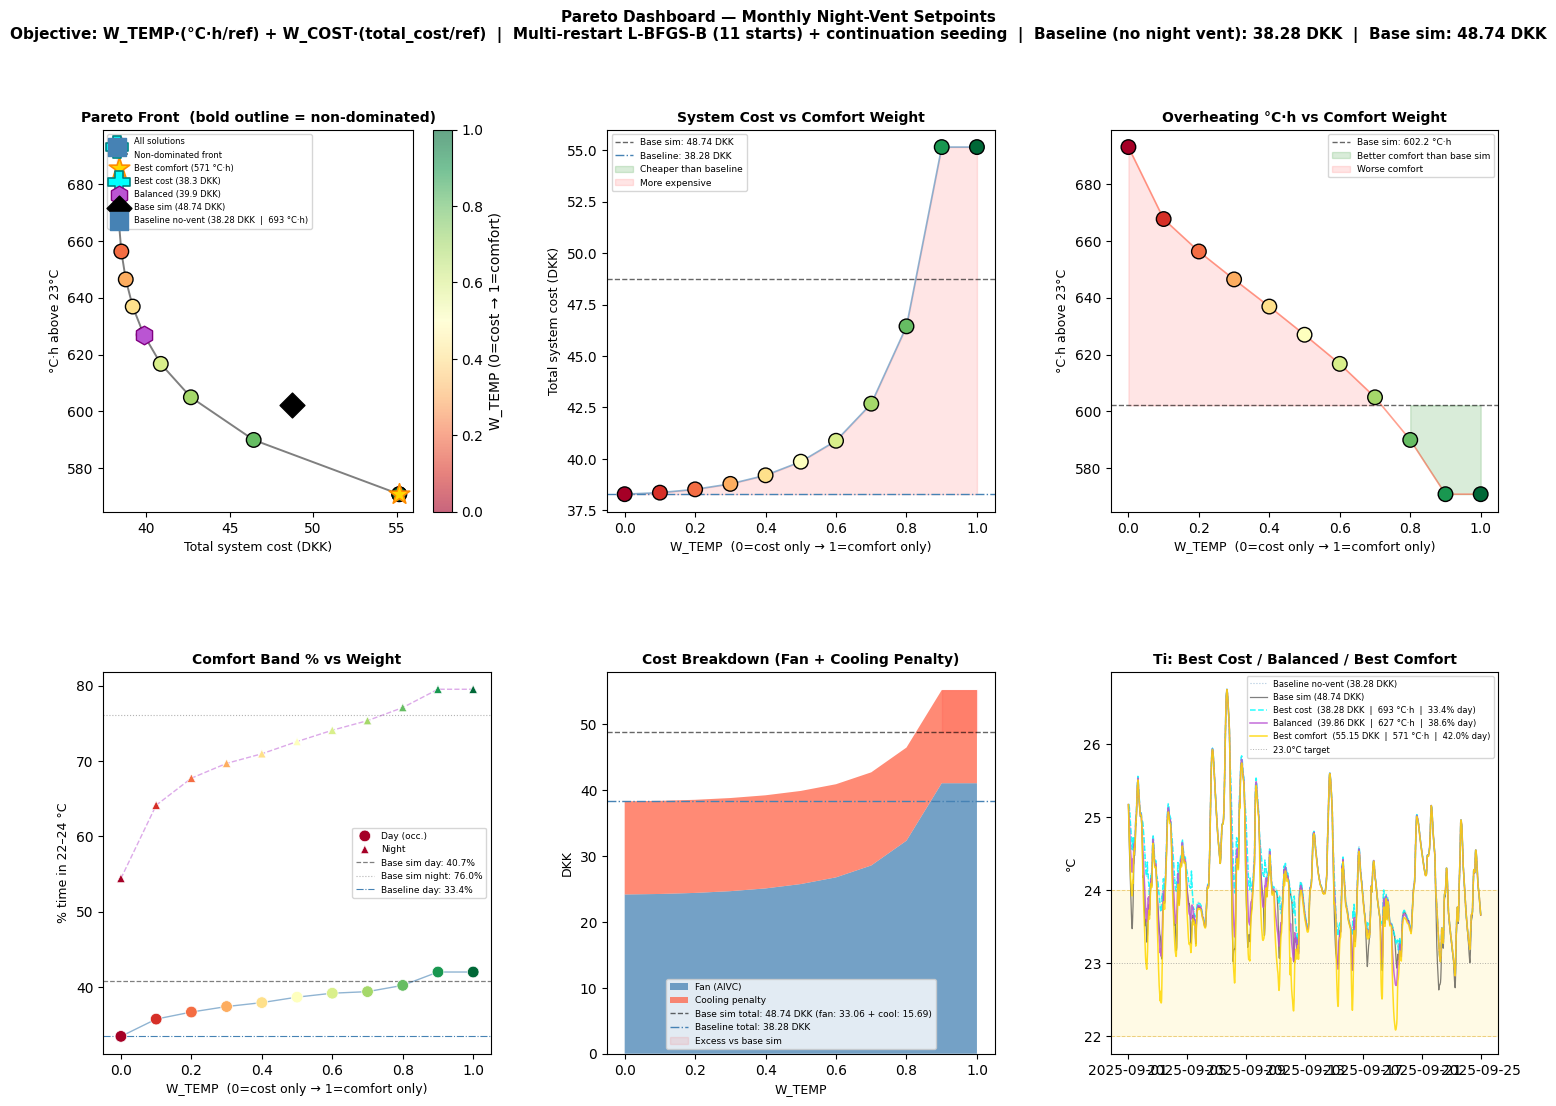

In [23]:
# ════════════════════════════════════════════════════════════════════════════
#  PARETO — MONTHLY SETPOINTS  (°C·h comfort  vs  total system cost)
#  Objective (normalised):
#    W_TEMP * (°C·h above 23°C / ref_dh)  +  W_COST * (total_cost / ref_cost)
#  Comparisons drawn vs BASELINE (no night vent).
#
#  Fixes vs previous version:
#    - Continuation seeding: each weight pair seeds from the previous solution
#    - NIGHT_START_LB lowered to 15h (was 18h — bound was always active)
#    - N_RESTARTS_P = 8 (was 3) for smoother front
#    - Pareto front post-processed to keep only non-dominated points
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec

# ── Tunable parameters ────────────────────────────────────────────────────────
N_RESTARTS_P          = 8
rng_p                 = np.random.default_rng(0)
NIGHT_START_LB_PARETO = 22.0
NIGHT_START_UB_PARETO = 22.0          # ← add this
NIGHT_STOP_LB_PARETO  = 7.0
NIGHT_STOP_UB_PARETO  = 7.0           # ← override the inherited value

MONTHLY_BOUNDS_PARETO = (
    [(NIGHT_START_LB_PARETO, NIGHT_START_UB_PARETO),   # (22, 22)
     (NIGHT_STOP_LB_PARETO,  NIGHT_STOP_UB_PARETO),    # ( 7,  7)
     (QV_MIN,                QV_MAX              )] * N_months
)

# ── Weight grid: 11 pairs, pure cost → pure comfort ───────────────────────────
_wt_vals     = np.linspace(0.0, 1.0, 11)
weight_pairs = [(round(w, 2), round(1.0 - w, 2)) for w in _wt_vals]

# ── Normalisation references ──────────────────────────────────────────────────
_ref_dh_norm   = dh_above_ref if dh_above_ref > 0 else 1.0
_ref_cost_norm = cost_ref     if cost_ref     > 0 else 1.0


def _obj_monthly_pareto(params, wt, wc):
    qv_mod, Tsup_mod = build_X_monthly(params)
    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod
    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti = np.asarray(result['Ti'])
    if not np.all(np.isfinite(Ti)):
        return 1e10
    dh_p   = float(np.sum(np.maximum(0.0, Ti - T_TARGET)) * dt_h)
    cost_p = total_system_cost(qv_mod, Ta_arr, Tsup_mod)
    return wt * (dh_p / _ref_dh_norm) + wc * (cost_p / _ref_cost_norm)


# ── Pareto sweep with continuation seeding ───────────────────────────────────
pareto_monthly = []
_prev_params   = np.tile([22.0, 7.0, QV_MAX * 0.5], N_months)   # initial seed

print(f"\n{'═'*80}")
print(f"  Pareto sweep — monthly setpoints  ({len(weight_pairs)} weight pairs × "
      f"{N_RESTARTS_P + 3} starts each)")
print(f"{'═'*80}")
print(f"  {'W_T/W_C':>9} {'°C·h':>8} {'Cost DKK':>9} "
      f"{'Day%':>7} {'Night%':>8} {'Δcost':>8} {'Start':>7} {'Stop':>6} {'qv':>6}")
print(f"{'─'*80}")

for W_T, W_C in weight_pairs:
    starts_p = [
        _prev_params.copy(),
        np.tile([22.0, 7.0, QV_MAX * 0.5], N_months),
        np.tile([22.0, 7.0, QV_MAX * W_T], N_months),  # ← fixed
    ]   
    for _ in range(N_RESTARTS_P):
        s = np.zeros(3 * N_months)
        for im in range(N_months):
            s[3*im]   = rng_p.uniform(NIGHT_START_LB_PARETO, NIGHT_START_UB_PARETO)
            s[3*im+1] = rng_p.uniform(NIGHT_STOP_LB_PARETO,  NIGHT_STOP_UB_PARETO)
            s[3*im+2] = rng_p.uniform(QV_MIN, QV_MAX)
        starts_p.append(s)

    best_res_p, best_fun_p = None, np.inf
    for x0_p in starts_p:
        r_p = minimize(
            _obj_monthly_pareto, x0_p,
            args=(W_T, W_C),
            method='L-BFGS-B',
            bounds=MONTHLY_BOUNDS_PARETO,
            options={'maxiter': 400, 'ftol': 1e-8, 'gtol': 1e-6, 'eps': 0.5}
        )
        if r_p.fun < best_fun_p:
            best_fun_p, best_res_p = r_p.fun, r_p

    # ── Post-process best solution ────────────────────────────────────────────
    params_p       = np.asarray(best_res_p.x)
    _prev_params   = params_p.copy()   # seed next weight pair (continuation)

    qv_p, Tsup_p   = build_X_monthly(params_p)
    X_p            = X_train.copy()
    X_p['qv']      = qv_p
    X_p['Tsup']    = Tsup_p
    sim_p          = simulate_night_vent_scenario(
        fitted_params, X_p, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti_p           = np.asarray(sim_p['Ti'])
    dh_p, _        = dh_from_target(Ti_p)
    dh_p_occ, _    = dh_from_target(Ti_p, mask=occ_mask)
    cost_p         = total_system_cost(qv_p, Ta_arr, Tsup_p)
    cost_p_fan     = fan_cost_aivc(qv_p)
    cost_p_cool    = q_cool_cost(qv_p, Ta_arr, Tsup_p)
    pct_d_p        = pct_in_band(Ti_p, T_cat1_min, T_cat1_max, occ_mask)
    pct_n_p        = pct_in_band(Ti_p, T_cat1_min, T_cat1_max, all_night_mask)

    # Decoded schedule for first month (printed inline)
    _h_s0 = params_p[0]; _h_e0 = params_p[1]; _qv0 = params_p[2]

    pareto_monthly.append({
        'W_TEMP': W_T, 'W_COST': W_C,
        'params': params_p,
        'dh_above': dh_p, 'dh_above_occ': dh_p_occ,
        'cost': cost_p, 'cost_fan': cost_p_fan, 'cost_cool': cost_p_cool,
        'pct_occ': pct_d_p, 'pct_night': pct_n_p,
        'Ti_arr': Ti_p, 'qv_arr': qv_p,
    })
    print(f"  {W_T:.2f}/{W_C:.2f}    {dh_p:>8.1f} {cost_p:>9.2f} "
          f"{pct_d_p:>6.1f}% {pct_n_p:>7.1f}% {cost_p - cost_ref:>+7.2f} "
          f"{_h_s0:>5.1f}h {_h_e0:>5.1f}h {_qv0:>5.0f}")

print(f"{'═'*80}")


# ── Post-process: extract non-dominated (true Pareto) front ──────────────────
def _is_nondominated(costs_arr, dhs_arr):
    """Returns boolean mask of non-dominated solutions (lower is better for both)."""
    n   = len(costs_arr)
    nd  = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if costs_arr[j] <= costs_arr[i] and dhs_arr[j] <= dhs_arr[i]:
                if costs_arr[j] < costs_arr[i] or dhs_arr[j] < dhs_arr[i]:
                    nd[i] = False
                    break
    return nd

_wt_p  = np.array([r['W_TEMP']    for r in pareto_monthly])
_dh_p  = np.array([r['dh_above']  for r in pareto_monthly])
_fc_p  = np.array([r['cost']      for r in pareto_monthly])
_po_p  = np.array([r['pct_occ']   for r in pareto_monthly])
_pn_p  = np.array([r['pct_night'] for r in pareto_monthly])

_nd_mask          = _is_nondominated(_fc_p, _dh_p)
_fc_nd            = _fc_p[_nd_mask]
_dh_nd            = _dh_p[_nd_mask]
_wt_nd            = _wt_p[_nd_mask]
_sort_nd          = np.argsort(_fc_nd)
_fc_nd_sorted     = _fc_nd[_sort_nd]
_dh_nd_sorted     = _dh_nd[_sort_nd]

idx_best_comfort  = int(np.argmin(_dh_p))
idx_best_cost     = int(np.argmin(_fc_p))
idx_mid           = len(pareto_monthly) // 2

print(f"\n  Non-dominated solutions: {_nd_mask.sum()} / {len(pareto_monthly)}")
print(f"\n  Best comfort  (W_T={pareto_monthly[idx_best_comfort]['W_TEMP']:.2f}):  "
      f"{_dh_p[idx_best_comfort]:.1f} °C·h  |  {_fc_p[idx_best_comfort]:.2f} DKK")
print(f"  Best cost     (W_C={pareto_monthly[idx_best_cost]['W_COST']:.2f}):  "
      f"{_dh_p[idx_best_cost]:.1f} °C·h  |  {_fc_p[idx_best_cost]:.2f} DKK")
print(f"  Balanced      (W_T={pareto_monthly[idx_mid]['W_TEMP']:.2f}):  "
      f"{_dh_p[idx_mid]:.1f} °C·h  |  {_fc_p[idx_mid]:.2f} DKK")

# ── Monthly schedules for extreme + balanced ──────────────────────────────────
for tag, idx_s in [('Best comfort', idx_best_comfort),
                   ('Balanced',     idx_mid),
                   ('Best cost',    idx_best_cost)]:
    print(f"\n  {tag} (W_T={pareto_monthly[idx_s]['W_TEMP']:.2f}):")
    print(f"  {'Month':<12} {'Start':>8} {'Stop':>8} {'qv [m³/h]':>12}")
    for i, m in enumerate(month_labels):
        pp = pareto_monthly[idx_s]['params']
        print(f"  {m:<12} {pp[3*i]:>7.1f}h {pp[3*i+1]:>7.1f}h {pp[3*i+2]:>12.1f}")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE — Pareto dashboard (monthly)
# ════════════════════════════════════════════════════════════════════════════
cmap_pw = plt.cm.RdYlGn
fig_par = plt.figure(figsize=(18, 12))
gs_par  = gridspec.GridSpec(2, 3, figure=fig_par, hspace=0.42, wspace=0.30)

fig_par.suptitle(
    'Pareto Dashboard — Monthly Night-Vent Setpoints\n'
    f'Objective: W_TEMP·(°C·h/ref) + W_COST·(total_cost/ref)  |  '
    f'Multi-restart L-BFGS-B ({N_RESTARTS_P + 3} starts) + continuation seeding  |  '
    f'Baseline (no night vent): {cost_baseline:.2f} DKK  |  '
    f'Base sim: {cost_ref:.2f} DKK',
    fontsize=11, fontweight='bold'
)

# ── Panel 0: Pareto front ─────────────────────────────────────────────────────
ax0 = fig_par.add_subplot(gs_par[0, 0])
sc0 = ax0.scatter(_fc_p, _dh_p, c=_wt_p, cmap=cmap_pw, s=70, zorder=3,
                  edgecolors='white', lw=0.6, vmin=0, vmax=1, alpha=0.6,
                  label='All solutions')
# Non-dominated front
ax0.plot(_fc_nd_sorted, _dh_nd_sorted, color='black', lw=1.4, ls='-',
         zorder=2, alpha=0.5, label='Non-dominated front')
ax0.scatter(_fc_nd, _dh_nd, c=_wt_nd, cmap=cmap_pw, s=110, zorder=4,
            edgecolors='black', lw=1.0, vmin=0, vmax=1)
# Extreme + balanced markers
ax0.scatter(_fc_p[idx_best_comfort], _dh_p[idx_best_comfort],
            s=240, marker='*', color='gold', edgecolors='darkorange', lw=1.2,
            zorder=6, label=f'Best comfort ({_dh_p[idx_best_comfort]:.0f} °C·h)')
ax0.scatter(_fc_p[idx_best_cost], _dh_p[idx_best_cost],
            s=240, marker='P', color='cyan', edgecolors='teal', lw=1.2,
            zorder=6, label=f'Best cost ({_fc_p[idx_best_cost]:.1f} DKK)')
ax0.scatter(_fc_p[idx_mid], _dh_p[idx_mid],
            s=180, marker='h', color='mediumorchid', edgecolors='purple', lw=1.0,
            zorder=6, label=f'Balanced ({_fc_p[idx_mid]:.1f} DKK)')
ax0.scatter(cost_ref,      dh_above_ref, s=160, marker='D', color='black',
            zorder=7, label=f'Base sim ({cost_ref:.2f} DKK)')
ax0.scatter(cost_baseline, dh_above_base, s=160, marker='s', color='steelblue',
            zorder=7, label=f'Baseline no-vent ({cost_baseline:.2f} DKK  |  {dh_above_base:.0f} °C·h)')
plt.colorbar(sc0, ax=ax0, label='W_TEMP (0=cost → 1=comfort)')
ax0.set_xlabel('Total system cost (DKK)', fontsize=9)
ax0.set_ylabel('°C·h above 23°C', fontsize=9)
ax0.set_title('Pareto Front  (bold outline = non-dominated)', fontsize=10, fontweight='bold')
ax0.legend(fontsize=6.0, loc='upper left')

# ── Panel 1: Cost vs W_TEMP ───────────────────────────────────────────────────
ax1 = fig_par.add_subplot(gs_par[0, 1])
ax1.scatter(_wt_p, _fc_p, c=_wt_p, cmap=cmap_pw, s=70, zorder=3,
            edgecolors='white', lw=0.5, vmin=0, vmax=1)
ax1.plot(_wt_p, _fc_p, color='steelblue', lw=1.2, alpha=0.6)
# Highlight non-dominated
ax1.scatter(_wt_nd, _fc_nd, s=110, c=_wt_nd, cmap=cmap_pw,
            edgecolors='black', lw=1.0, vmin=0, vmax=1, zorder=4)
ax1.axhline(cost_ref,      color='black',     lw=1.0, ls='--', alpha=0.6,
            label=f'Base sim: {cost_ref:.2f} DKK')
ax1.axhline(cost_baseline, color='steelblue', lw=1.0, ls='-.',
            label=f'Baseline: {cost_baseline:.2f} DKK')
ax1.fill_between(_wt_p, _fc_p, cost_baseline,
    where=(_fc_p < cost_baseline), alpha=0.15, color='green',
    label='Cheaper than baseline')
ax1.fill_between(_wt_p, _fc_p, cost_baseline,
    where=(_fc_p >= cost_baseline), alpha=0.10, color='red',
    label='More expensive')
ax1.set_xlabel('W_TEMP  (0=cost only → 1=comfort only)', fontsize=9)
ax1.set_ylabel('Total system cost (DKK)', fontsize=9)
ax1.set_title('System Cost vs Comfort Weight', fontsize=10, fontweight='bold')
ax1.legend(fontsize=6.5)

# ── Panel 2: °C·h vs W_TEMP ──────────────────────────────────────────────────
ax2 = fig_par.add_subplot(gs_par[0, 2])
ax2.scatter(_wt_p, _dh_p, c=_wt_p, cmap=cmap_pw, s=70, zorder=3,
            edgecolors='white', lw=0.5, vmin=0, vmax=1)
ax2.plot(_wt_p, _dh_p, color='tomato', lw=1.2, alpha=0.6)
ax2.scatter(_wt_nd, _dh_nd, s=110, c=_wt_nd, cmap=cmap_pw,
            edgecolors='black', lw=1.0, vmin=0, vmax=1, zorder=4)
ax2.axhline(dh_above_ref, color='black', lw=1.0, ls='--', alpha=0.6,
            label=f'Base sim: {dh_above_ref:.1f} °C·h')
ax2.fill_between(_wt_p, _dh_p, dh_above_ref,
    where=(_dh_p < dh_above_ref), alpha=0.15, color='green',
    label='Better comfort than base sim')
ax2.fill_between(_wt_p, _dh_p, dh_above_ref,
    where=(_dh_p >= dh_above_ref), alpha=0.10, color='red',
    label='Worse comfort')
ax2.set_xlabel('W_TEMP  (0=cost only → 1=comfort only)', fontsize=9)
ax2.set_ylabel('°C·h above 23°C', fontsize=9)
ax2.set_title('Overheating °C·h vs Comfort Weight', fontsize=10, fontweight='bold')
ax2.legend(fontsize=6.5)

# ── Panel 3: % in band vs W_TEMP ─────────────────────────────────────────────
ax3 = fig_par.add_subplot(gs_par[1, 0])
ax3.scatter(_wt_p, _po_p, c=_wt_p, cmap=cmap_pw, s=70, zorder=3,
            edgecolors='white', lw=0.5, vmin=0, vmax=1, label='Day (occ.)')
ax3.scatter(_wt_p, _pn_p, c=_wt_p, cmap=cmap_pw, s=35, marker='^', zorder=3,
            edgecolors='white', lw=0.4, vmin=0, vmax=1, label='Night')
ax3.plot(_wt_p, _po_p, color='steelblue',    lw=1.0, alpha=0.6)
ax3.plot(_wt_p, _pn_p, color='mediumorchid', lw=1.0, alpha=0.5, ls='--')
ax3.axhline(pct_occ_ref,   color='black',     lw=0.9, ls='--', alpha=0.5,
            label=f'Base sim day: {pct_occ_ref:.1f}%')
ax3.axhline(pct_night_ref, color='dimgray',   lw=0.8, ls=':',  alpha=0.5,
            label=f'Base sim night: {pct_night_ref:.1f}%')
ax3.axhline(pct_occ_base,  color='steelblue', lw=0.8, ls='-.',
            label=f'Baseline day: {pct_occ_base:.1f}%')
ax3.set_xlabel('W_TEMP  (0=cost only → 1=comfort only)', fontsize=9)
ax3.set_ylabel('% time in 22–24 °C', fontsize=9)
ax3.set_title('Comfort Band % vs Weight', fontsize=10, fontweight='bold')
ax3.legend(fontsize=6.5)

# ── Panel 4: Cost breakdown stacked ──────────────────────────────────────────
ax4 = fig_par.add_subplot(gs_par[1, 1])
_fc_fan_arr  = np.array([r['cost_fan']  for r in pareto_monthly])
_fc_cool_arr = np.array([r['cost_cool'] for r in pareto_monthly])
ax4.stackplot(_wt_p, _fc_fan_arr, _fc_cool_arr,
              labels=['Fan (AIVC)', 'Cooling penalty'],
              colors=['steelblue', 'tomato'], alpha=0.75)
ax4.axhline(cost_ref,      color='black',     lw=1.0, ls='--', alpha=0.6,
            label=f'Base sim total: {cost_ref:.2f} DKK '
                  f'(fan: {cost_ref_fan:.2f} + cool: {cost_ref_cool:.2f})')
ax4.axhline(cost_baseline, color='steelblue', lw=1.0, ls='-.',
            label=f'Baseline total: {cost_baseline:.2f} DKK')
# Mark where night-vent fan cost exceeds base sim fan cost
_total_arr = _fc_fan_arr + _fc_cool_arr
ax4.fill_between(_wt_p, _total_arr, cost_ref,
    where=(_total_arr > cost_ref), alpha=0.08, color='red',
    label='Excess vs base sim')
ax4.set_xlabel('W_TEMP', fontsize=9)
ax4.set_ylabel('DKK', fontsize=9)
ax4.set_title('Cost Breakdown (Fan + Cooling Penalty)', fontsize=10, fontweight='bold')
ax4.legend(fontsize=6.5)

# ── Panel 5: Ti time series — 3 selected solutions ────────────────────────────
ax5 = fig_par.add_subplot(gs_par[1, 2])
selected = [
    (idx_best_cost,    'Best cost',    'cyan',         '--'),
    (idx_mid,          'Balanced',     'mediumorchid', '-'),
    (idx_best_comfort, 'Best comfort', 'gold',         '-'),
]
ax5.plot(index, np.asarray(baseline['Ti']), color='steelblue', lw=0.8,
         alpha=0.45, ls=':', label=f'Baseline no-vent ({cost_baseline:.2f} DKK)')
ax5.plot(index, Ti_ref, color='black', lw=0.9, alpha=0.5,
         label=f'Base sim ({cost_ref:.2f} DKK)')
for idx_sel, lbl, col, ls in selected:
    r_sel = pareto_monthly[idx_sel]
    ax5.plot(index, r_sel['Ti_arr'], color=col, lw=1.1, ls=ls, alpha=0.85,
             label=f'{lbl}  ({r_sel["cost"]:.2f} DKK  |  '
                   f'{r_sel["dh_above"]:.0f} °C·h  |  {r_sel["pct_occ"]:.1f}% day)')
ax5.axhspan(T_cat1_min, T_cat1_max, alpha=0.10, color='gold')
ax5.axhline(T_cat1_max, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
ax5.axhline(T_cat1_min, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
ax5.axhline(T_TARGET,   color='grey',      lw=0.7, ls=':',  alpha=0.6,
            label=f'{T_TARGET}°C target')
ax5.set_ylabel('°C', fontsize=9)
ax5.set_title('Ti: Best Cost / Balanced / Best Comfort', fontsize=10, fontweight='bold')
ax5.legend(fontsize=6.0)

plt.savefig('pareto_monthly_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


══════════════════════════════════════════════════════════════════════
  ISO-COST OPTIMISATION — Maximum comfort at fixed budget
  Base sim total cost:   48.74 DKK
  Baseline (no-vent):    38.28 DKK
══════════════════════════════════════════════════════════════════════

  ── Budget A — baseline cost  (budget = 38.28 DKK) ──
  °C·h above 23°C:    608.41   (base sim: 602.16,  Δ = +6.25)
  Day comfort %:       35.8%  (base sim: 40.7%)
  Night comfort %:     76.9%  (base sim: 76.0%)
  Total cost:          38.28 DKK  (fan: 25.97  +  cooling: 12.31)
  Budget used:        100.0%

  Month         NightStart  NightStop   qv_night   DayFrac
  ──────────────────────────────────────────────────────────
  2025-09           22.0h       7.0h      207.2      0.86

  ── Budget B — base sim cost  (budget = 48.74 DKK) ──
  °C·h above 23°C:    583.19   (base sim: 602.16,  Δ = -18.97)
  Day comfort %:       40.1%  (base sim: 40.7%)
  Night comfort %:     78.5%  (base sim: 76.0%)
  Total cost:          48.

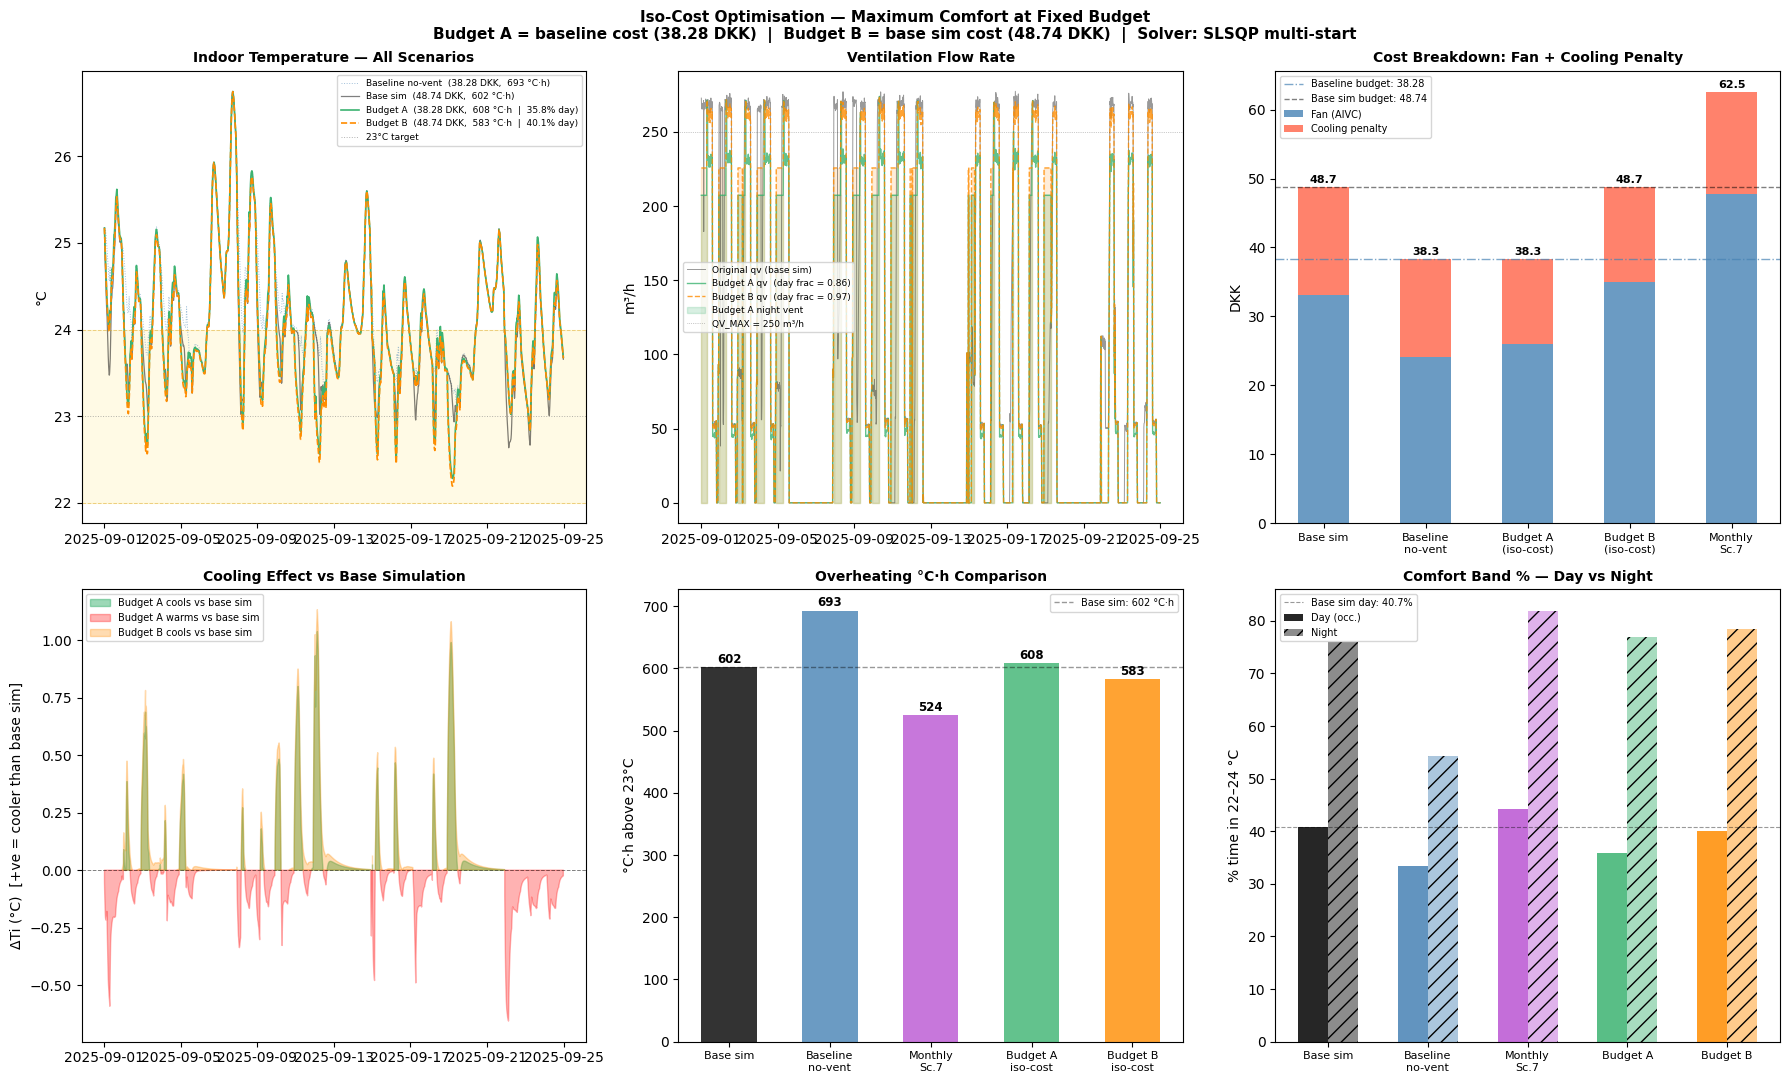

In [24]:
# ════════════════════════════════════════════════════════════════════════════
#  ISO-COST OPTIMISATION — Best comfort for a fixed cost budget
#
#  Key idea:
#    Daytime qv can be scaled DOWN  →  less hot outdoor air pushed through
#    chiller  →  Q_cool penalty drops  →  budget freed for night fan.
#
#  Extended monthly layout (4 params/month):
#    [night_start_h, night_stop_h, qv_night, qv_day_frac]
#    qv_day_frac ∈ [0, 1]  ← scales original measured daytime qv
#
#  Objective  : minimise °C·h above 23°C  (all hours)
#  Constraint : total_system_cost  ≤  BUDGET
#
#  Two budget levels solved and compared:
#    A. BUDGET_A = cost_baseline   (38.28 DKK) — "free" comfort improvement
#    B. BUDGET_B = cost_ref        (48.74 DKK) — best comfort for current spend
#
#  Solver: SLSQP (supports inequality constraints natively)
# ════════════════════════════════════════════════════════════════════════════

# ── Extended bounds (4 params per month) ─────────────────────────────────────
ISO_NIGHT_START_LB = 22.0
ISO_NIGHT_START_UB = 22.0
ISO_NIGHT_STOP_LB  =  7.0
ISO_NIGHT_STOP_UB  =  7.0

MONTHLY_BOUNDS_ISO = (
    [(ISO_NIGHT_START_LB, ISO_NIGHT_START_UB),   # night start
     (ISO_NIGHT_STOP_LB,  ISO_NIGHT_STOP_UB),    # night stop
     (QV_MIN,             QV_MAX),                # night qv
     (0.0,                1.0)                   # day qv fraction
    ] * N_months
)

N_ISO_PARAMS = 4 * N_months


def build_X_monthly_iso(params):
    """
    Extended build: daytime qv scaled by qv_day_frac, night as usual.
    Reducing qv_day_frac lowers Q_cool penalty (less warm air cooled by chiller).
    """
    params   = np.asarray(params, dtype=float)
    qv_mod   = np.asarray(X_train['qv'],   dtype=float).copy()
    Tsup_mod = np.asarray(X_train['Tsup'], dtype=float).copy()

    for i, month in enumerate(months_in_data):
        h_start     = float(np.clip(params[4*i],     ISO_NIGHT_START_LB, ISO_NIGHT_START_UB))
        h_stop      = float(np.clip(params[4*i + 1], ISO_NIGHT_STOP_LB,  ISO_NIGHT_STOP_UB))
        qv_val      = float(np.clip(params[4*i + 2], QV_MIN,             QV_MAX))
        qv_day_frac = float(np.clip(params[4*i + 3], 0.0,                1.0))

        month_m = (month_periods == month)

        # ── Daytime: scale original measured flow ─────────────────────────────
        day_m             = month_m & weekday_day_mask
        qv_mod[day_m]     = qv_arr[day_m] * qv_day_frac
        # Tsup stays as measured during the day

        # ── Night window ──────────────────────────────────────────────────────
        if h_start > h_stop:
            night_m = (hours >= h_start) | (hours < h_stop)
        else:
            night_m = (hours >= h_start) & (hours < h_stop)

        mask_n     = month_m & night_m & _wday_check
        eligible   = mask_n & ta_ok_mask
        suppressed = mask_n & ~ta_ok_mask

        qv_mod[eligible]   = qv_val
        qv_mod[suppressed] = 0.0
        Tsup_mod[eligible] = Ta_arr[eligible]

    return qv_mod, Tsup_mod


def _iso_objective(params):
    """Minimise °C·h above 23°C."""
    qv_mod, Tsup_mod = build_X_monthly_iso(params)
    X_mod         = X_train.copy()
    X_mod['qv']   = qv_mod
    X_mod['Tsup'] = Tsup_mod
    result = simulate_night_vent_scenario(
        fitted_params, X_mod, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti = np.asarray(result['Ti'])
    if not np.all(np.isfinite(Ti)):
        return 1e10
    return float(np.sum(np.maximum(0.0, Ti - T_TARGET)) * dt_h)


def _iso_cost_value(params):
    """Return total system cost — used both as constraint and for reporting."""
    qv_mod, Tsup_mod = build_X_monthly_iso(params)
    return total_system_cost(qv_mod, Ta_arr, Tsup_mod)


def _make_cost_constraint(budget):
    """Returns SLSQP inequality dict: budget - cost ≥ 0."""
    return {'type': 'ineq', 'fun': lambda p: budget - _iso_cost_value(p)}


def _run_iso_opt(budget, label, n_restarts=5, rng_seed=42):
    """
    Multi-start SLSQP.  Returns best (params, Ti_arr, qv_arr, Tsup_arr, cost, dh).
    """
    rng_iso = np.random.default_rng(rng_seed)
    constraint = _make_cost_constraint(budget)

    # Starting points
    starts = [
        np.tile([22.0, 7.0, QV_MAX * 0.5, 1.0], N_months),
        np.tile([22.0, 7.0, QV_MAX * 0.8, 0.7], N_months),
        np.tile([22.0, 7.0, QV_MAX * 0.3, 0.9], N_months),
        np.tile([22.0, 7.0, QV_MAX,       0.5], N_months),
    ]
    for _ in range(n_restarts):
        s = np.zeros(N_ISO_PARAMS)
        for im in range(N_months):
            s[4*im]   = rng_iso.uniform(ISO_NIGHT_START_LB, ISO_NIGHT_START_UB)
            s[4*im+1] = rng_iso.uniform(ISO_NIGHT_STOP_LB,  ISO_NIGHT_STOP_UB)
            s[4*im+2] = rng_iso.uniform(QV_MIN,              QV_MAX)
            s[4*im+3] = rng_iso.uniform(0.3,                 1.0)
        starts.append(s)

    best_fun, best_params = np.inf, starts[0]
    for x0 in starts:
        try:
            r = minimize(
                _iso_objective, x0,
                method='SLSQP',
                bounds=MONTHLY_BOUNDS_ISO,
                constraints=constraint,
                options={'maxiter': 600, 'ftol': 1e-8, 'disp': False}
            )
            # Accept only feasible solutions (cost ≤ budget + 0.01 tolerance)
            if r.fun < best_fun and _iso_cost_value(r.x) <= budget + 0.01:
                best_fun, best_params = r.fun, r.x
        except Exception:
            continue

    params_opt       = np.asarray(best_params)
    qv_opt, Tsup_opt = build_X_monthly_iso(params_opt)
    X_opt            = X_train.copy()
    X_opt['qv']      = qv_opt
    X_opt['Tsup']    = Tsup_opt
    sim_opt          = simulate_night_vent_scenario(
        fitted_params, X_opt, N_hist,
        night_start_hour=0, night_stop_hour=0, qv_night=0,
        rec_duration=rec_duration,
        Ti_init=Ti_init, Tm_init=Tm_init, c_init=c_init)
    Ti_opt       = np.asarray(sim_opt['Ti'])
    dh_opt, _    = dh_from_target(Ti_opt)
    dh_opt_occ,_ = dh_from_target(Ti_opt, mask=occ_mask)
    cost_opt     = _iso_cost_value(params_opt)
    cost_fan_opt = fan_cost_aivc(qv_opt)
    cost_cool_opt= q_cool_cost(qv_opt, Ta_arr, Tsup_opt)
    pct_d_opt    = pct_in_band(Ti_opt, T_cat1_min, T_cat1_max, occ_mask)
    pct_n_opt    = pct_in_band(Ti_opt, T_cat1_min, T_cat1_max, all_night_mask)

    print(f"\n  ── {label}  (budget = {budget:.2f} DKK) ──")
    print(f"  °C·h above 23°C:  {dh_opt:>8.2f}   (base sim: {dh_above_ref:.2f},  "
          f"Δ = {dh_opt - dh_above_ref:+.2f})")
    print(f"  Day comfort %:    {pct_d_opt:>7.1f}%  (base sim: {pct_occ_ref:.1f}%)")
    print(f"  Night comfort %:  {pct_n_opt:>7.1f}%  (base sim: {pct_night_ref:.1f}%)")
    print(f"  Total cost:       {cost_opt:>8.2f} DKK  "
          f"(fan: {cost_fan_opt:.2f}  +  cooling: {cost_cool_opt:.2f})")
    print(f"  Budget used:      {cost_opt/budget*100:>7.1f}%")
    print(f"\n  {'Month':<12} {'NightStart':>11} {'NightStop':>10} "
          f"{'qv_night':>10} {'DayFrac':>9}")
    print(f"  {'─'*58}")
    for i, m in enumerate(month_labels):
        p = params_opt
        print(f"  {m:<12} {p[4*i]:>9.1f}h  {p[4*i+1]:>8.1f}h  "
              f"{p[4*i+2]:>9.1f}  {p[4*i+3]:>8.2f}")

    return {
        'label': label, 'budget': budget,
        'params': params_opt, 'Ti_arr': Ti_opt, 'qv_arr': qv_opt,
        'dh_above': dh_opt, 'dh_above_occ': dh_opt_occ,
        'cost': cost_opt, 'cost_fan': cost_fan_opt, 'cost_cool': cost_cool_opt,
        'pct_occ': pct_d_opt, 'pct_night': pct_n_opt,
    }


# ── Run both budget levels ────────────────────────────────────────────────────
print(f"\n{'═'*70}")
print(f"  ISO-COST OPTIMISATION — Maximum comfort at fixed budget")
print(f"  Base sim total cost:   {cost_ref:.2f} DKK")
print(f"  Baseline (no-vent):    {cost_baseline:.2f} DKK")
print(f"{'═'*70}")

iso_A = _run_iso_opt(cost_baseline, 'Budget A — baseline cost', n_restarts=6)
iso_B = _run_iso_opt(cost_ref,      'Budget B — base sim cost', n_restarts=6)

# ── Summary vs all scenarios ──────────────────────────────────────────────────
print(f"\n{'═'*78}")
print(f"  {'Scenario':<38} {'°C·h':>8} {'Day%':>7} {'Night%':>8} {'DKK':>8}")
print(f"{'─'*78}")
iso_rows = [
    ('Base simulation',              dh_above_ref,         pct_occ_ref,     pct_night_ref,     cost_ref),
    ('Baseline — no night vent',     dh_above_base,  pct_occ_base, pct_night_base, cost_baseline),
    ('Monthly setpoints Sc.7',       dh_above_mo7,         pct_occ_monthly, pct_night_monthly, cost_monthly),
    (iso_A['label'],                 iso_A['dh_above'],    iso_A['pct_occ'],iso_A['pct_night'],iso_A['cost']),
    (iso_B['label'],                 iso_B['dh_above'],    iso_B['pct_occ'],iso_B['pct_night'],iso_B['cost']),
]
for label, dh, pd_, pn, c in iso_rows:
    print(f"  {label:<38} {dh:>8.1f} {pd_:>6.1f}% {pn:>7.1f}% {c:>8.2f}")
print(f"{'═'*78}")


# ════════════════════════════════════════════════════════════════════════════
#  FIGURE — ISO-COST dashboard
# ════════════════════════════════════════════════════════════════════════════
fig_iso, axes_iso = plt.subplots(2, 3, figsize=(18, 11))
fig_iso.suptitle(
    'Iso-Cost Optimisation — Maximum Comfort at Fixed Budget\n'
    f'Budget A = baseline cost ({cost_baseline:.2f} DKK)  |  '
    f'Budget B = base sim cost ({cost_ref:.2f} DKK)  |  '
    f'Solver: SLSQP multi-start',
    fontsize=11, fontweight='bold'
)

colors_iso = {'A': 'mediumseagreen', 'B': 'darkorange'}

# ── Panel 0: Ti time series ────────────────────────────────────────────────────
ax = axes_iso[0, 0]
ax.plot(index, np.asarray(baseline['Ti']), color='steelblue', lw=0.7,
        ls=':', alpha=0.5, label=f'Baseline no-vent  ({cost_baseline:.2f} DKK,  '
                                  f'{dh_above_base:.0f} °C·h)')
ax.plot(index, Ti_ref, color='black', lw=0.9, alpha=0.5,
        label=f'Base sim  ({cost_ref:.2f} DKK,  {dh_above_ref:.0f} °C·h)')
ax.plot(index, iso_A['Ti_arr'], color=colors_iso['A'], lw=1.2,
        label=f"Budget A  ({iso_A['cost']:.2f} DKK,  {iso_A['dh_above']:.0f} °C·h  |  "
              f"{iso_A['pct_occ']:.1f}% day)")
ax.plot(index, iso_B['Ti_arr'], color=colors_iso['B'], lw=1.2, ls='--',
        label=f"Budget B  ({iso_B['cost']:.2f} DKK,  {iso_B['dh_above']:.0f} °C·h  |  "
              f"{iso_B['pct_occ']:.1f}% day)")
ax.axhspan(T_cat1_min, T_cat1_max, alpha=0.10, color='gold')
ax.axhline(T_cat1_max, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
ax.axhline(T_cat1_min, color='goldenrod', lw=0.7, ls='--', alpha=0.5)
ax.axhline(T_TARGET,   color='grey',      lw=0.7, ls=':',  alpha=0.6,
           label='23°C target')
ax.set_ylabel('°C'); ax.legend(fontsize=6.5)
ax.set_title('Indoor Temperature — All Scenarios', fontsize=10, fontweight='bold')

# ── Panel 1: qv time series ────────────────────────────────────────────────────
ax = axes_iso[0, 1]
ax.plot(index, qv_arr, color='black', lw=0.7, alpha=0.4, label='Original qv (base sim)')
ax.plot(index, iso_A['qv_arr'], color=colors_iso['A'], lw=1.0, alpha=0.8,
        label=f"Budget A qv  (day frac = {iso_A['params'][3]:.2f})")
ax.plot(index, iso_B['qv_arr'], color=colors_iso['B'], lw=1.0, alpha=0.8, ls='--',
        label=f"Budget B qv  (day frac = {iso_B['params'][3]:.2f})")
ax.fill_between(index, iso_A['qv_arr'], 0,
    where=weekday_night_mask & ta_ok_mask, alpha=0.2, color=colors_iso['A'],
    label='Budget A night vent')
ax.fill_between(index, iso_B['qv_arr'], 0,
    where=weekday_night_mask & ta_ok_mask, alpha=0.15, color=colors_iso['B'])
ax.axhline(QV_MAX, color='black', lw=0.5, ls=':', alpha=0.4,
           label=f'QV_MAX = {QV_MAX:.0f} m³/h')
ax.set_ylabel('m³/h'); ax.legend(fontsize=6.5)
ax.set_title('Ventilation Flow Rate', fontsize=10, fontweight='bold')

# ── Panel 2: Cost breakdown bar ────────────────────────────────────────────────
ax = axes_iso[0, 2]
scenarios_bar = [
    ('Base sim',       cost_ref_fan,           cost_ref_cool),
    ('Baseline\nno-vent', fan_cost_aivc(qv_baseline), q_cool_cost(qv_baseline, Ta_arr, Tsup_base)),
    ('Budget A\n(iso-cost)', iso_A['cost_fan'],  iso_A['cost_cool']),
    ('Budget B\n(iso-cost)', iso_B['cost_fan'],  iso_B['cost_cool']),
    ('Monthly\nSc.7',   cost_mo7_fan,           cost_mo7_cool),
]
x_bar  = np.arange(len(scenarios_bar))
w_bar  = 0.5
b_fan  = ax.bar(x_bar, [s[1] for s in scenarios_bar], w_bar,
                label='Fan (AIVC)', color='steelblue', alpha=0.8)
b_cool = ax.bar(x_bar, [s[2] for s in scenarios_bar], w_bar,
                bottom=[s[1] for s in scenarios_bar],
                label='Cooling penalty', color='tomato', alpha=0.8)
for xi, (lbl, fan, cool) in zip(x_bar, scenarios_bar):
    ax.text(xi, fan + cool + 0.3, f'{fan+cool:.1f}', ha='center',
            va='bottom', fontsize=8, fontweight='bold')
ax.axhline(cost_baseline, color='steelblue', lw=1.0, ls='-.', alpha=0.7,
           label=f'Baseline budget: {cost_baseline:.2f}')
ax.axhline(cost_ref,      color='black',     lw=1.0, ls='--', alpha=0.5,
           label=f'Base sim budget: {cost_ref:.2f}')
ax.set_xticks(x_bar)
ax.set_xticklabels([s[0] for s in scenarios_bar], fontsize=8)
ax.set_ylabel('DKK'); ax.legend(fontsize=7)
ax.set_title('Cost Breakdown: Fan + Cooling Penalty', fontsize=10, fontweight='bold')

# ── Panel 3: ΔTi = Ti_base - Ti_iso (cooling effect of night vent) ────────────
ax = axes_iso[1, 0]
delta_A = Ti_ref - iso_A['Ti_arr']
delta_B = Ti_ref - iso_B['Ti_arr']
ax.fill_between(index, delta_A, 0, where=(delta_A > 0),
    alpha=0.5, color=colors_iso['A'], label='Budget A cools vs base sim')
ax.fill_between(index, delta_A, 0, where=(delta_A < 0),
    alpha=0.3, color='red', label='Budget A warms vs base sim')
ax.fill_between(index, delta_B, 0, where=(delta_B > 0),
    alpha=0.3, color=colors_iso['B'], label='Budget B cools vs base sim')
ax.axhline(0, color='black', lw=0.7, ls='--', alpha=0.5)
ax.set_ylabel('ΔTi (°C)  [+ve = cooler than base sim]')
ax.legend(fontsize=7)
ax.set_title('Cooling Effect vs Base Simulation', fontsize=10, fontweight='bold')

# ── Panel 4: °C·h comparison bar ──────────────────────────────────────────────
ax = axes_iso[1, 1]
dh_bars = [
    ('Base sim',      dh_above_ref,         'black'),
    ('Baseline\nno-vent', dh_above_base,     'steelblue'),  # same Ti
    ('Monthly\nSc.7', dh_above_mo7,         'mediumorchid'),
    ('Budget A\niso-cost', iso_A['dh_above'], colors_iso['A']),
    ('Budget B\niso-cost', iso_B['dh_above'], colors_iso['B']),
]
x_dh   = np.arange(len(dh_bars))
bars_dh = ax.bar(x_dh, [d[1] for d in dh_bars],
                 color=[d[2] for d in dh_bars], alpha=0.8, width=0.55)
for b, (lbl, val, col) in zip(bars_dh, dh_bars):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.axhline(dh_above_ref, color='black', lw=1.0, ls='--', alpha=0.4,
           label=f'Base sim: {dh_above_ref:.0f} °C·h')
ax.set_xticks(x_dh)
ax.set_xticklabels([d[0] for d in dh_bars], fontsize=8)
ax.set_ylabel('°C·h above 23°C'); ax.legend(fontsize=7)
ax.set_title('Overheating °C·h Comparison', fontsize=10, fontweight='bold')

# ── Panel 5: Day % comfort comparison ─────────────────────────────────────────
ax = axes_iso[1, 2]
pct_bars = [
    ('Base sim',       pct_occ_ref,        pct_night_ref,    'black'),
    ('Baseline\nno-vent', pct_occ_base,    pct_night_base,   'steelblue'),
    ('Monthly\nSc.7',  pct_occ_monthly,   pct_night_monthly, 'mediumorchid'),
    ('Budget A',       iso_A['pct_occ'],  iso_A['pct_night'], colors_iso['A']),
    ('Budget B',       iso_B['pct_occ'],  iso_B['pct_night'], colors_iso['B']),
]
x_pct = np.arange(len(pct_bars))
w_pct = 0.3
ax.bar(x_pct - w_pct/2, [p[1] for p in pct_bars], w_pct,
       color=[p[3] for p in pct_bars], alpha=0.85, label='Day (occ.)')
ax.bar(x_pct + w_pct/2, [p[2] for p in pct_bars], w_pct,
       color=[p[3] for p in pct_bars], alpha=0.45, hatch='//', label='Night')
ax.axhline(pct_occ_ref,   color='black',  lw=0.8, ls='--', alpha=0.4,
           label=f'Base sim day: {pct_occ_ref:.1f}%')
ax.set_xticks(x_pct)
ax.set_xticklabels([p[0] for p in pct_bars], fontsize=8)
ax.set_ylabel('% time in 22–24 °C'); ax.legend(fontsize=7)
ax.set_title('Comfort Band % — Day vs Night', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('iso_cost_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()